In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [14]:

# ── Data ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(r'D:\transfer_RL\plots for RL\timeseries.csv')
df['hour']  = df['time_step'] % 24
df['day']   = df['time_step'] // 24
df['month'] = pd.cut(df['day'], bins=[-1,30,58,89,119,150,180,211,242,272,303,333,366],
                     labels=['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'])
# week sample: pick week 20 (mid-year) — 7 days × 24 = 168 rows
WEEK_START = 20 * 24
week = df.iloc[WEEK_START:WEEK_START+168].copy().reset_index(drop=True)


In [31]:
# Output directory for saved high-res PNGs
output_dir = 'TD3_Evaluation_Plots'
os.makedirs(output_dir, exist_ok=True)
#── Output folder ─────────────────────────────────────────────────────────────
OUT = r"D:\transfer_RL\Result_Figure\Result_figure_2"
os.makedirs(OUT, exist_ok=True)


In [50]:


# ── Style ─────────────────────────────────────────────────────────────────────
BLUE   = '#2E86AB'
ORANGE = '#E07B39'
GREEN  = '#27AE60'
RED    = '#C0392B'
PURPLE = '#8E44AD'
TEAL   = '#16A085'
GRAY   = '#7F8C8D'
LGRAY  = '#ECF0F1'
C_TD3  = '#1f77b4'       # Blue
C_BASE = '#d62728'      # Red
C_PV   = '#2ca02c'        # Green
C_ACENT= '#ff7f0e'    # Orange

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#E8E8E8',
    'grid.linewidth': 0.6,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.85,
    'legend.edgecolor': '#CCCCCC',
})

def save(fig, name):
    fig.savefig(f'D:\\transfer_RL\\{name}', facecolor='white')
    print(f'  saved {name}')
    plt.show()

  saved plot01_cumulative_kpis.png


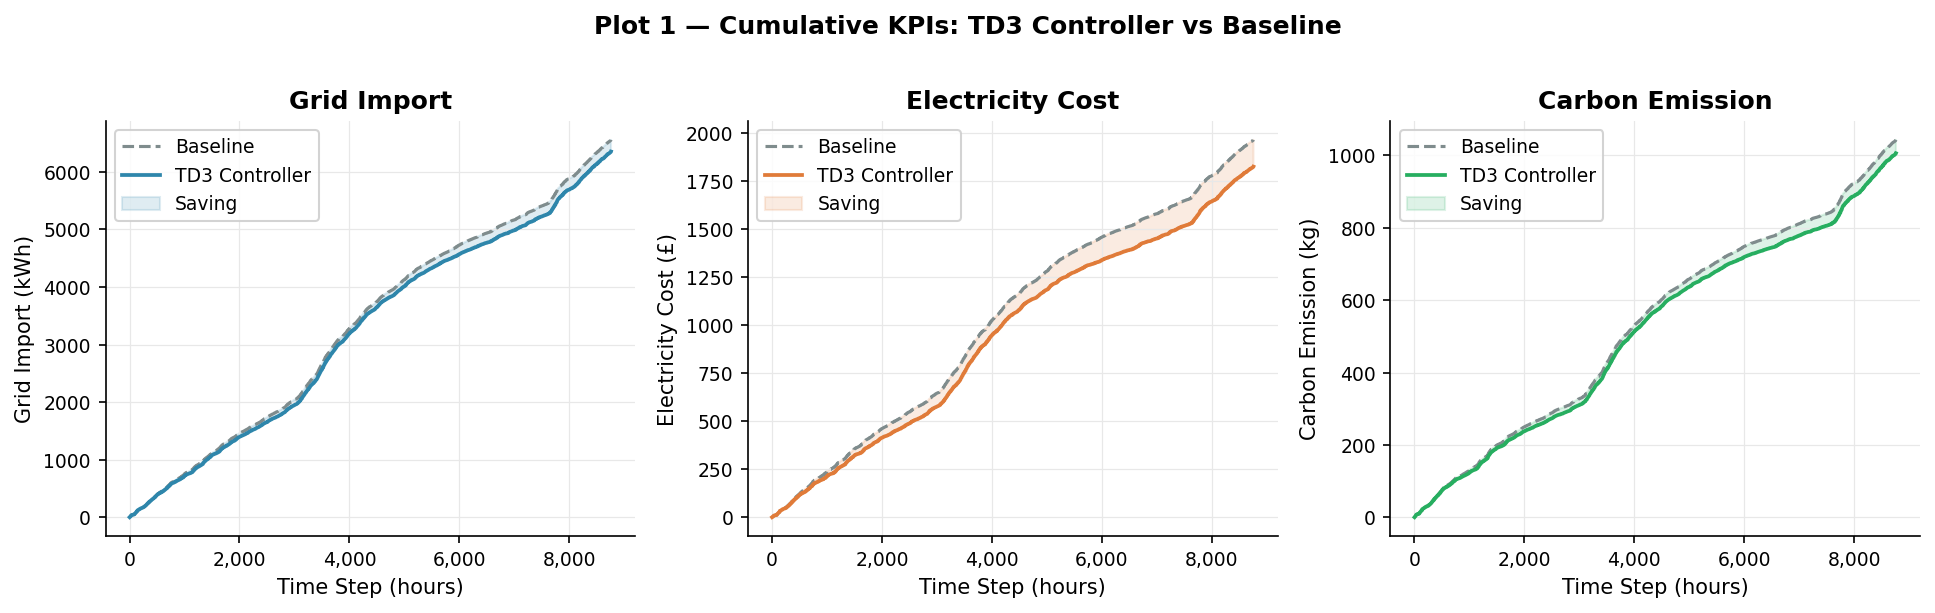

In [16]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Cumulative KPIs: controller vs baseline
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kpi_pairs = [
    ('grid_import', 'baseline_grid_import', 'Grid Import (kWh)', BLUE),
    ('positive_electricity_cost', 'positive_baseline_cost', 'Electricity Cost (£)', ORANGE),
    ('positive_carbon_emission', 'positive_baseline_emission', 'Carbon Emission (kg)', GREEN),
]
for ax, (ctrl_col, base_col, ylabel, color) in zip(axes, kpi_pairs):
    ctrl_cum = df[ctrl_col].cumsum()
    base_cum = df[base_col].cumsum()
    ax.plot(df['time_step'], base_cum, color=GRAY, lw=1.5, ls='--', label='Baseline', zorder=2)
    ax.plot(df['time_step'], ctrl_cum, color=color, lw=1.8, label='TD3 Controller', zorder=3)
    ax.fill_between(df['time_step'], ctrl_cum, base_cum,
                    where=(ctrl_cum < base_cum), alpha=0.15, color=color, label='Saving')
    ax.set_xlabel('Time Step (hours)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(' (')[0])
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.suptitle('Plot 1 — Cumulative KPIs: TD3 Controller vs Baseline', fontweight='bold', y=1.01)
plt.tight_layout()
save(fig, 'plot01_cumulative_kpis.png')


  saved plot02_pct_improvement.png


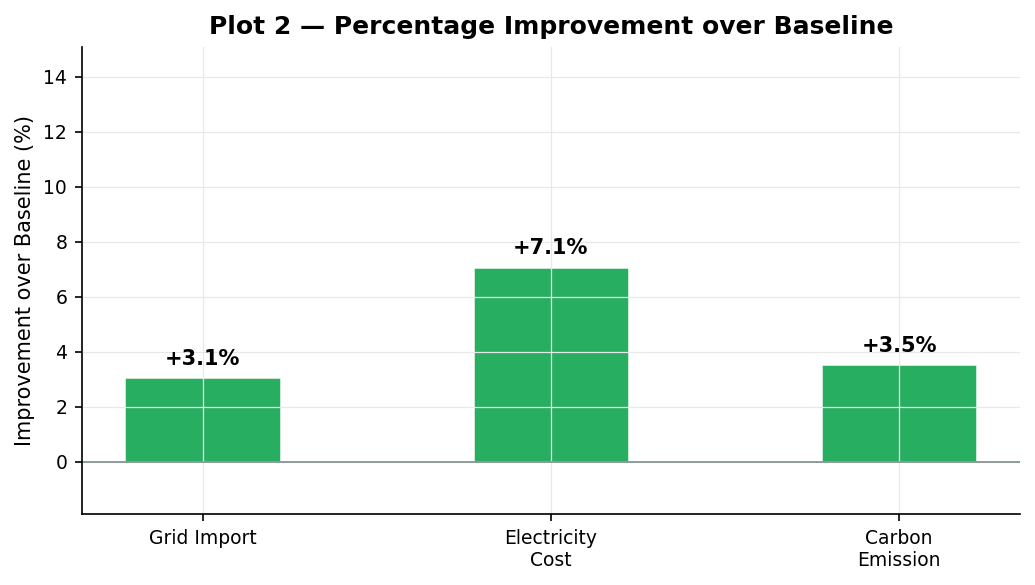

In [17]:


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Percentage improvement over baseline
# ══════════════════════════════════════════════════════════════════════════════
EPS = 1e-8
metrics = {
    'Grid Import': (df['grid_import'].sum(), df['baseline_grid_import'].sum()),
    'Electricity\nCost': (df['positive_electricity_cost'].sum(), df['positive_baseline_cost'].sum()),
    'Carbon\nEmission': (df['positive_carbon_emission'].sum(), df['positive_baseline_emission'].sum()),
}
labels, improvements, bar_colors = [], [], []
for label, (ctrl, base) in metrics.items():
    imp = 100 * (base - ctrl) / (base + EPS)
    labels.append(label)
    improvements.append(imp)
    bar_colors.append(GREEN if imp >= 0 else RED)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, improvements, color=bar_colors, width=0.45, edgecolor='white', linewidth=1.2)
ax.axhline(0, color=GRAY, lw=0.8)
for bar, val in zip(bars, improvements):
    sign = '+' if val >= 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.3 if val >= 0 else -0.8),
            f'{sign}{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylabel('Improvement over Baseline (%)')
ax.set_title('Plot 2 — Percentage Improvement over Baseline')
ax.set_ylim(min(improvements) - 5, max(improvements) + 8)
plt.tight_layout()
save(fig, 'plot02_pct_improvement.png')


  saved plot03_weekly_profile.png


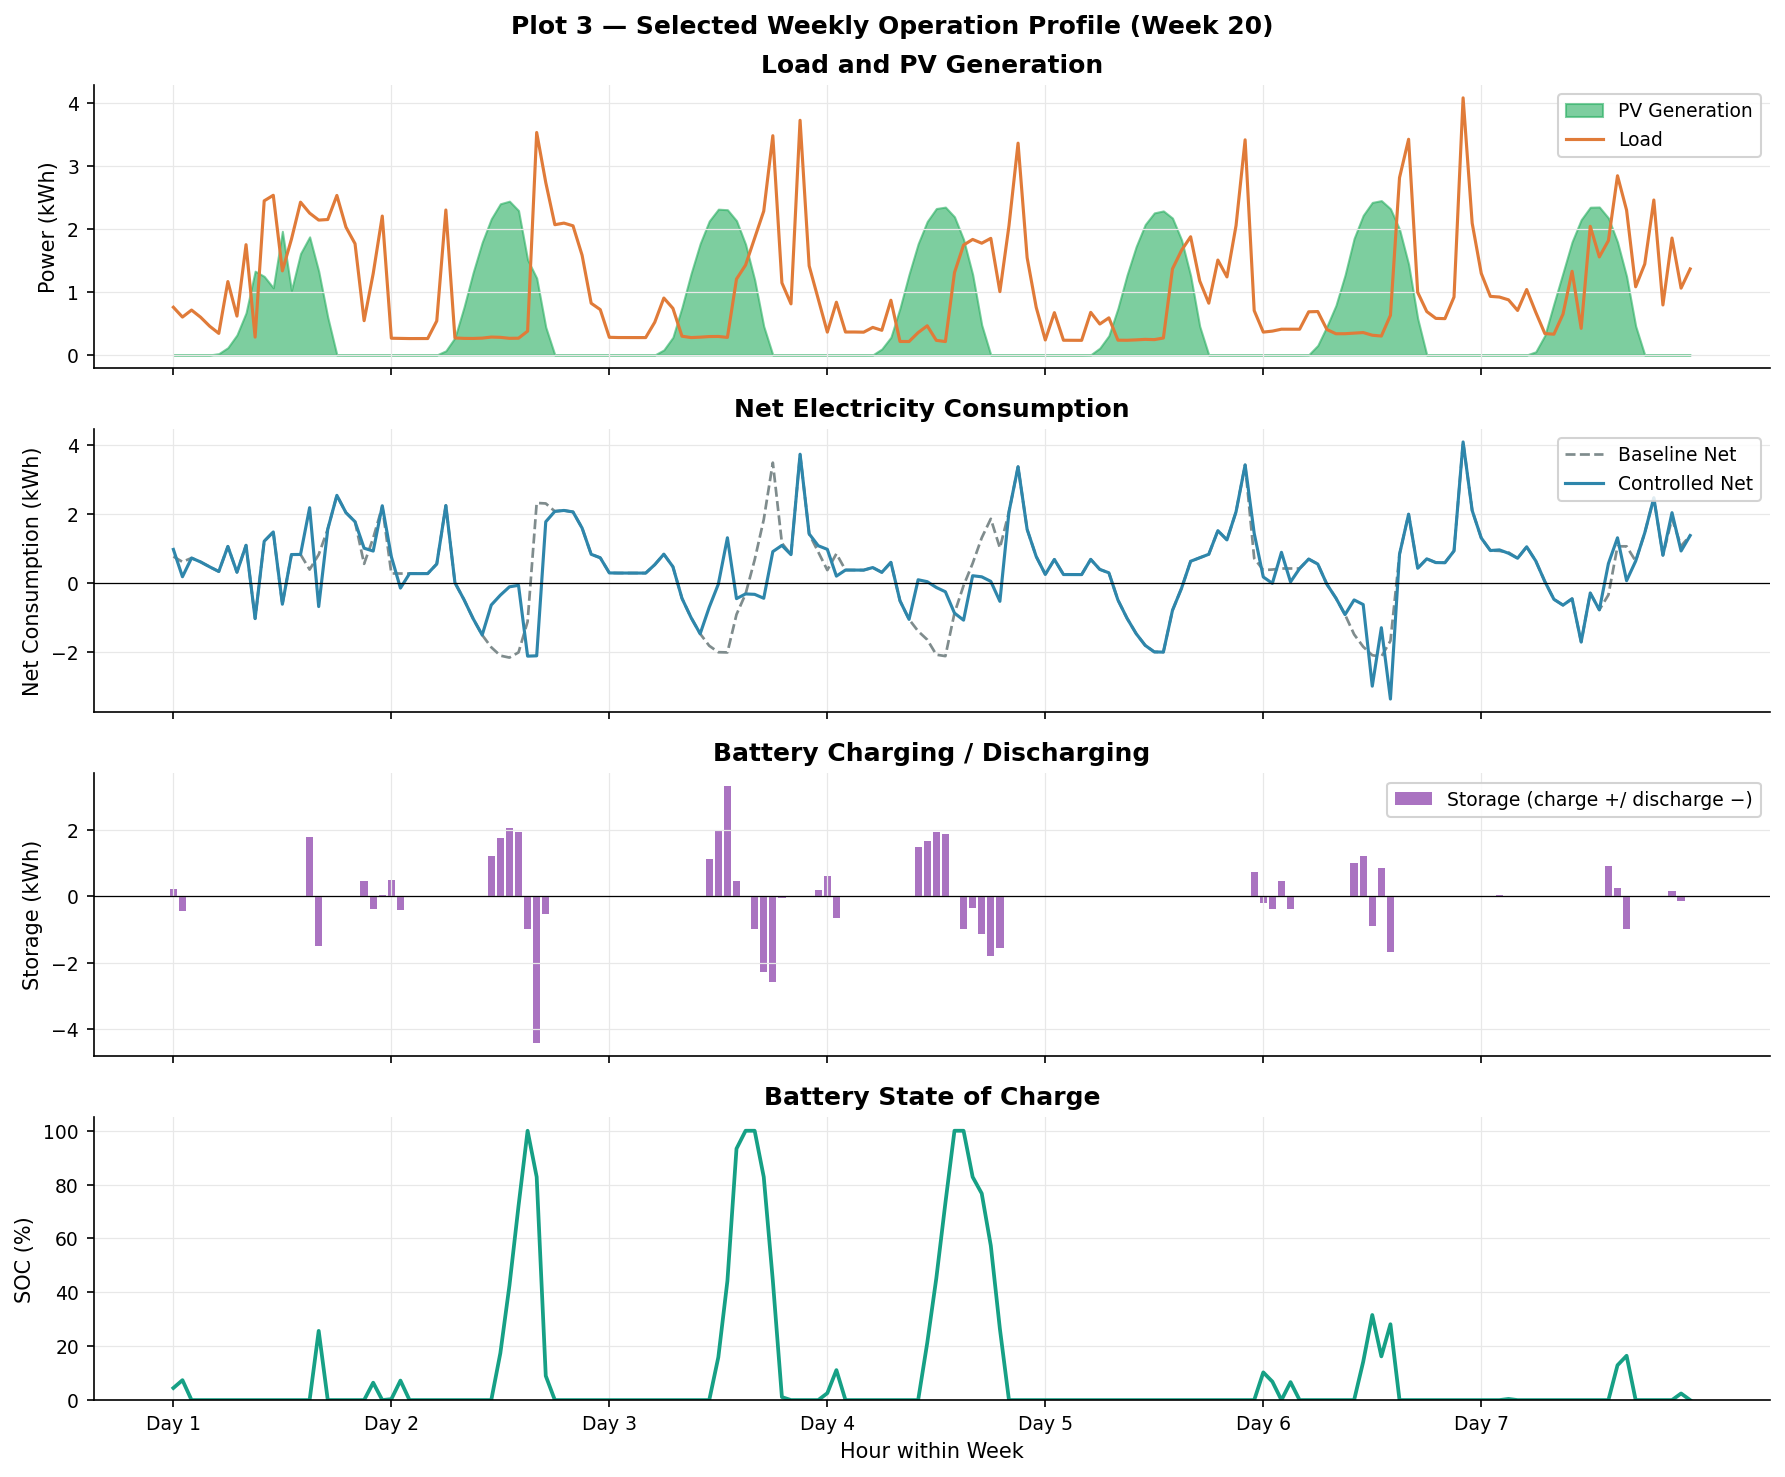

In [18]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Selected weekly operation profile (week 20)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
hours = week.index

axes[0].fill_between(hours, week['pv_generation_positive'], alpha=0.6, color=GREEN, label='PV Generation')
axes[0].plot(hours, week['non_shiftable_load'], color=ORANGE, lw=1.5, label='Load')
axes[0].set_ylabel('Power (kWh)')
axes[0].set_title('Load and PV Generation')
axes[0].legend(loc='upper right')

axes[1].plot(hours, week['net_baseline'], color=GRAY, lw=1.3, ls='--', label='Baseline Net')
axes[1].plot(hours, week['net_consumption'], color=BLUE, lw=1.5, label='Controlled Net')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_ylabel('Net Consumption (kWh)')
axes[1].set_title('Net Electricity Consumption')
axes[1].legend(loc='upper right')

axes[2].bar(hours, week['storage_electricity_consumption'], color=PURPLE, width=0.8,
            alpha=0.75, label='Storage (charge +/ discharge −)')
axes[2].axhline(0, color='black', lw=0.6)
axes[2].set_ylabel('Storage (kWh)')
axes[2].set_title('Battery Charging / Discharging')
axes[2].legend(loc='upper right')

axes[3].plot(hours, week['battery_soc_percent'], color=TEAL, lw=1.8)
axes[3].set_ylabel('SOC (%)')
axes[3].set_ylim(0, 105)
axes[3].set_title('Battery State of Charge')
axes[3].set_xlabel('Hour within Week')

tick_positions = list(range(0, 168, 24))
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels([f'Day {i+1}' for i in range(7)])

fig.suptitle('Plot 3 — Selected Weekly Operation Profile (Week 20)', fontweight='bold')
plt.tight_layout()
save(fig, 'plot03_weekly_profile.png')


  saved plot04_net_consumption.png


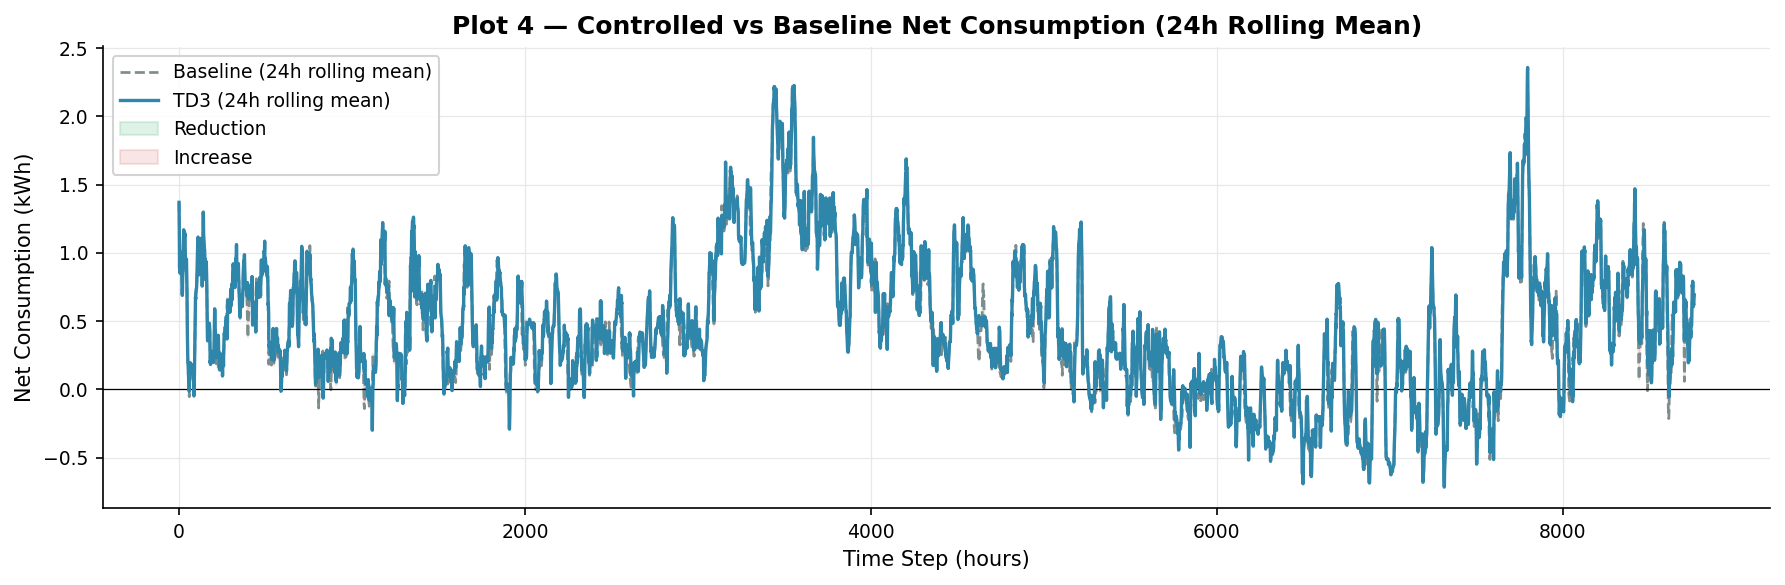

In [19]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Controlled and baseline net consumption (rolling daily mean)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 4))
roll = 24
ctrl_roll = df['net_consumption'].rolling(roll, min_periods=1).mean()
base_roll = df['net_baseline'].rolling(roll, min_periods=1).mean()
ax.plot(df['time_step'], base_roll, color=GRAY, lw=1.3, ls='--', label='Baseline (24h rolling mean)')
ax.plot(df['time_step'], ctrl_roll, color=BLUE, lw=1.6, label='TD3 (24h rolling mean)', zorder=3)
ax.fill_between(df['time_step'], ctrl_roll, base_roll,
                where=(ctrl_roll < base_roll), alpha=0.15, color=GREEN, label='Reduction')
ax.fill_between(df['time_step'], ctrl_roll, base_roll,
                where=(ctrl_roll > base_roll), alpha=0.12, color=RED, label='Increase')
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Time Step (hours)')
ax.set_ylabel('Net Consumption (kWh)')
ax.set_title('Plot 4 — Controlled vs Baseline Net Consumption (24h Rolling Mean)')
ax.legend()
plt.tight_layout()
save(fig, 'plot04_net_consumption.png')


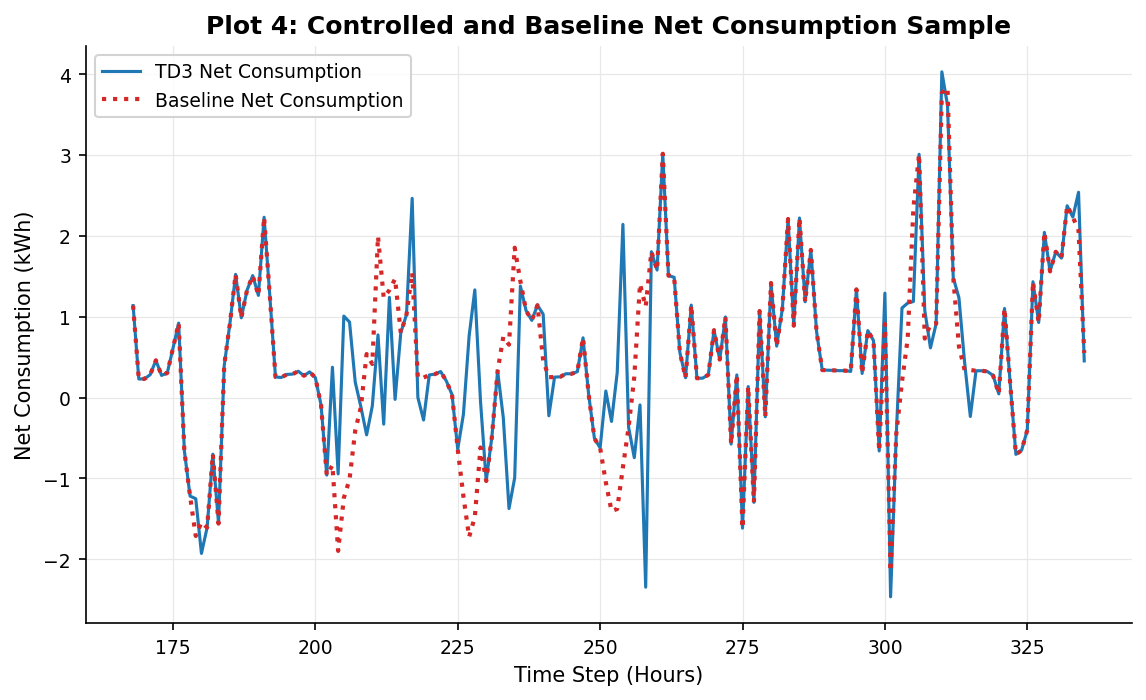

In [51]:
# ==========================================
# Plot 4: Controlled and Baseline Net Consumption
# ==========================================
plt.figure(figsize=(9, 5))
week_df = df[(df['time_step'] >= 168) & (df['time_step'] < 336)] # Week 2 sample
plt.plot(week_df['time_step'], week_df['net_consumption'], label='TD3 Net Consumption', color=C_TD3)
plt.plot(week_df['time_step'], week_df['net_baseline'], label='Baseline Net Consumption', color=C_BASE, linestyle=':', linewidth=2)
plt.xlabel('Time Step (Hours)')
plt.ylabel('Net Consumption (kWh)')
plt.title('Plot 4: Controlled and Baseline Net Consumption Sample')
plt.legend()
plt.savefig(f'{output_dir}/Plot_04_Net_Consumption.png', dpi=300)
plt.show()


  saved plot05_soc_action.png


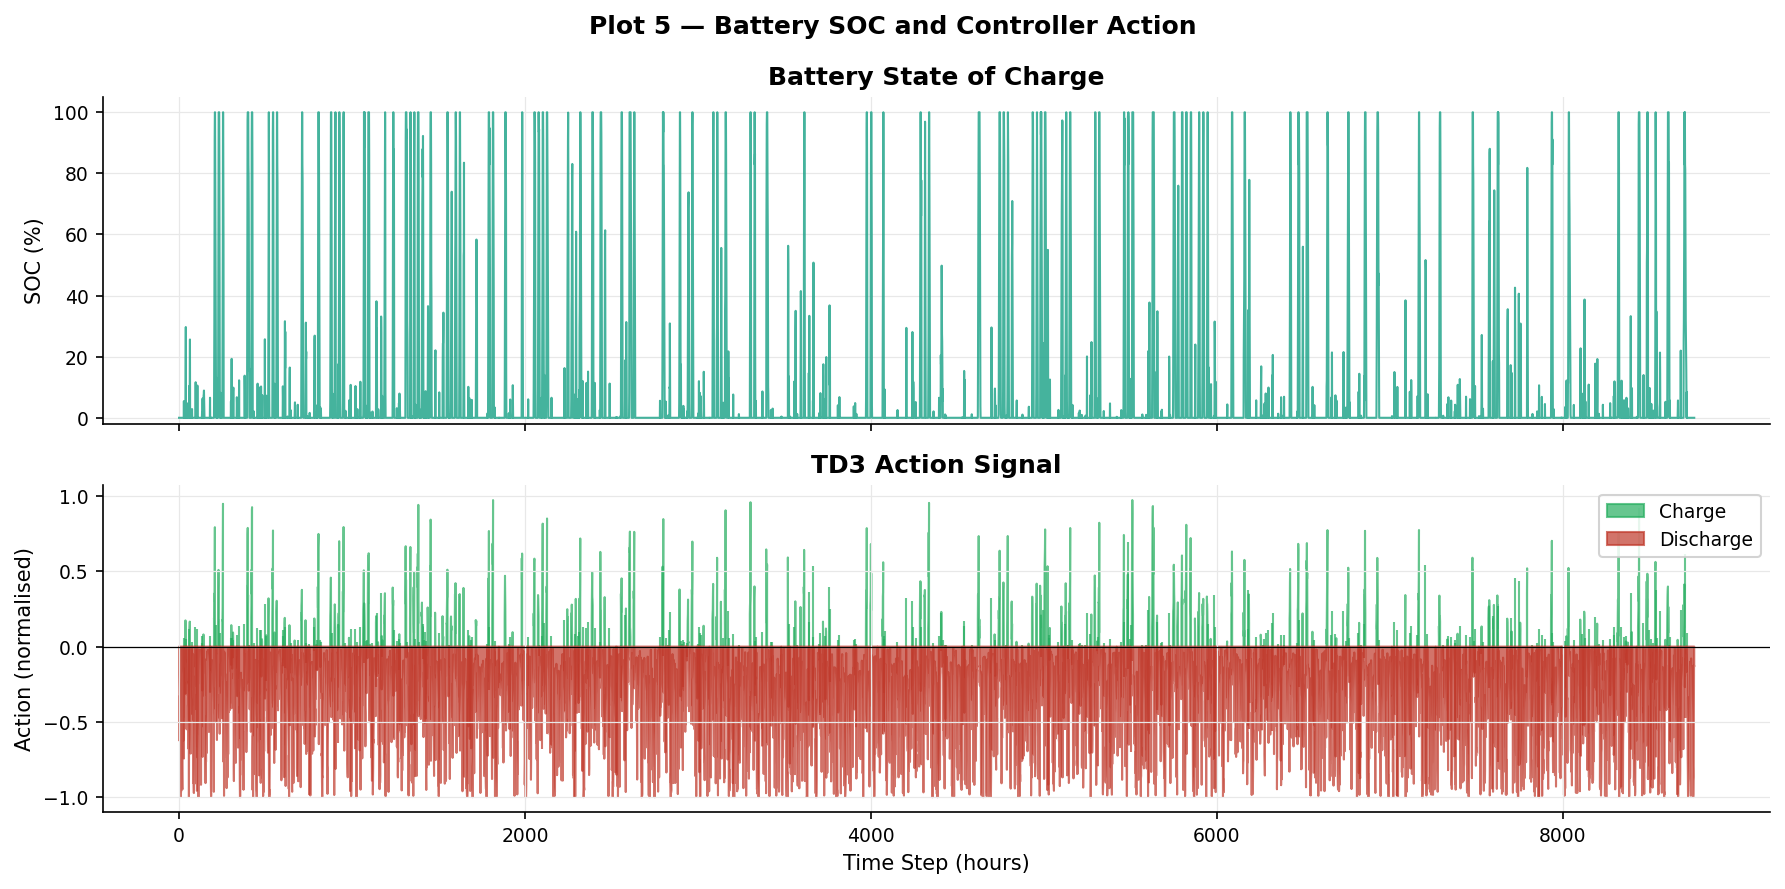

In [20]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — Battery SOC and action
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(df['time_step'], df['battery_soc_percent'], color=TEAL, lw=1.0, alpha=0.8)
ax1.set_ylabel('SOC (%)')
ax1.set_ylim(-2, 105)
ax1.set_title('Battery State of Charge')

ax2.fill_between(df['time_step'], df['action'], 0,
                 where=(df['action'] >= 0), color=GREEN, alpha=0.7, label='Charge')
ax2.fill_between(df['time_step'], df['action'], 0,
                 where=(df['action'] < 0), color=RED, alpha=0.7, label='Discharge')
ax2.axhline(0, color='black', lw=0.6)
ax2.set_ylabel('Action (normalised)')
ax2.set_xlabel('Time Step (hours)')
ax2.set_title('TD3 Action Signal')
ax2.legend()

fig.suptitle('Plot 5 — Battery SOC and Controller Action', fontweight='bold')
plt.tight_layout()
save(fig, 'plot05_soc_action.png')


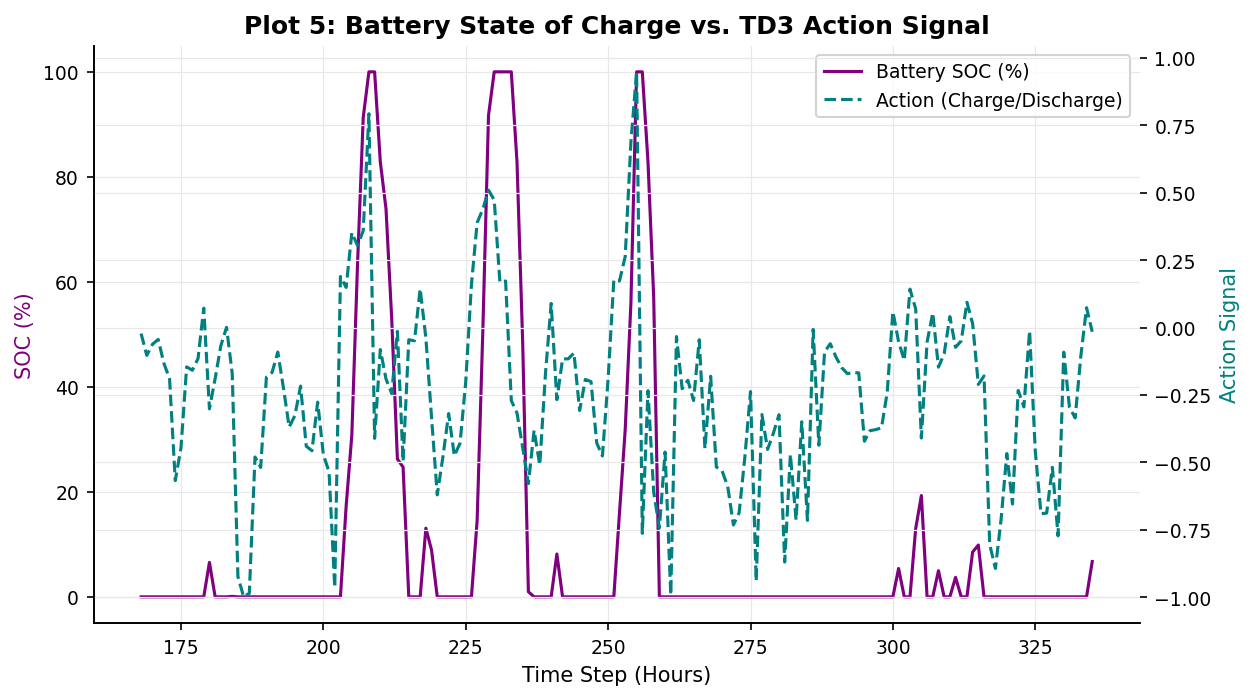

In [ ]:
# ==========================================
# Plot 5: Battery SOC and Action new
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
week_df = df[(df['time_step'] >= 168) & (df['time_step'] < 336)] # Week 2 sample
l1 = ax1.plot(week_df['time_step'], week_df['battery_soc_percent'], color='purple', label='Battery SOC (%)')
l2 = ax2.plot(week_df['time_step'], week_df['action'], color='teal', linestyle='--', label='Action (Charge/Discharge)')

ax1.set_xlabel('Time Step (Hours)')
ax1.set_ylabel('SOC (%)', color='purple')
ax2.set_ylabel('Action Signal', color='teal')
ax1.set_title('Plot 5: Battery State of Charge vs. TD3 Action Signal')

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.savefig(f'{output_dir}/Plot_05_Battery_SOC_and_Action.png', dpi=300)
plt.show()


  saved plot06_soc_distribution.png


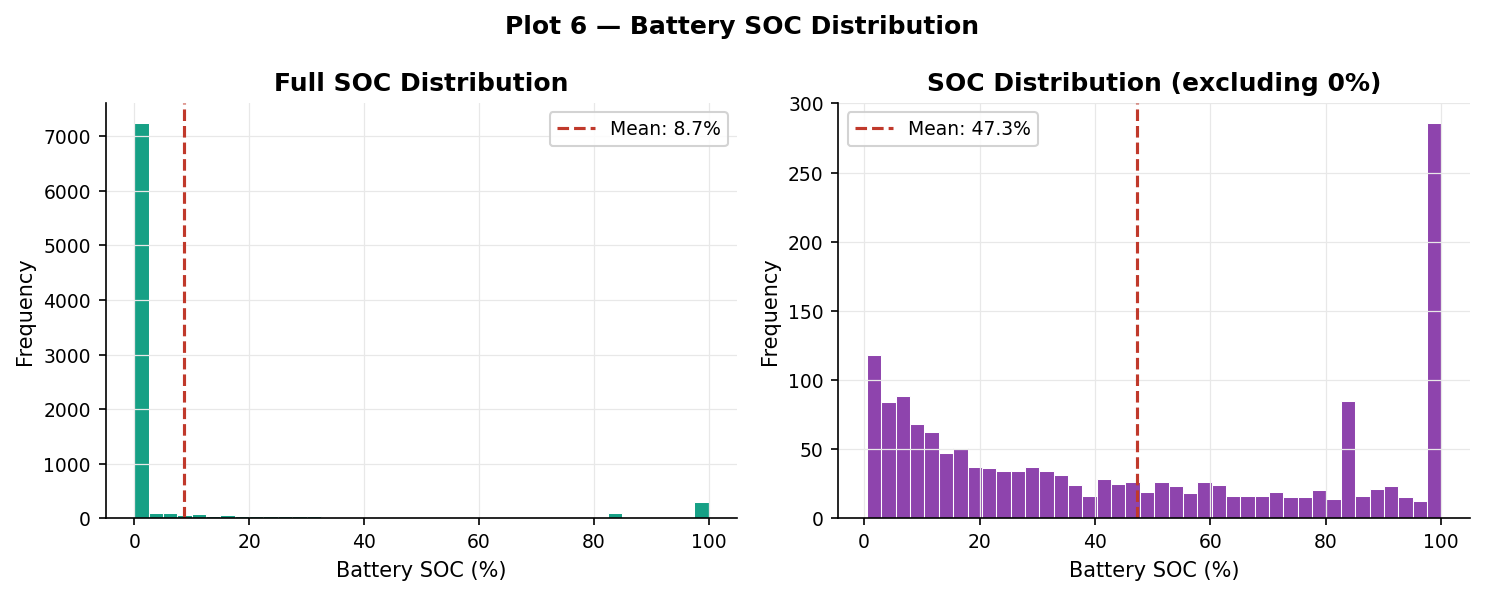

In [21]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — SOC distribution
# ══════════════════════════════════════════════════════════════════════════════
soc_nonzero = df.loc[df['battery_soc_percent'] > 0.5, 'battery_soc_percent']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(df['battery_soc_percent'], bins=40, color=TEAL, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Battery SOC (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Full SOC Distribution')
ax1.axvline(df['battery_soc_percent'].mean(), color=RED, lw=1.5, ls='--',
            label=f"Mean: {df['battery_soc_percent'].mean():.1f}%")
ax1.legend()

ax2.hist(soc_nonzero, bins=40, color=PURPLE, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Battery SOC (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('SOC Distribution (excluding 0%)')
ax2.axvline(soc_nonzero.mean(), color=RED, lw=1.5, ls='--',
            label=f"Mean: {soc_nonzero.mean():.1f}%")
ax2.legend()

fig.suptitle('Plot 6 — Battery SOC Distribution', fontweight='bold')
plt.tight_layout()
save(fig, 'plot06_soc_distribution.png')


  saved plot07_charge_discharge.png


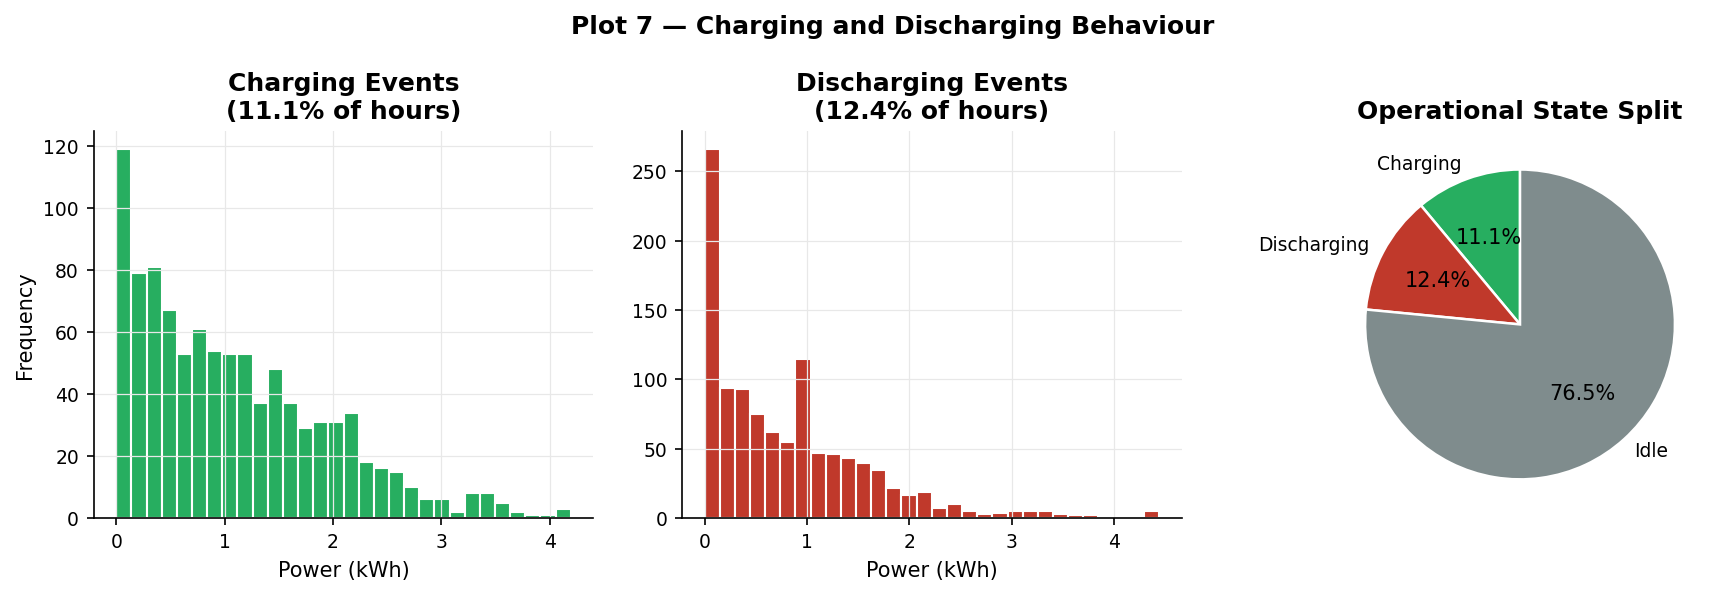

In [22]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 7 — Charging and discharging behavior
# ══════════════════════════════════════════════════════════════════════════════
charge    = df.loc[df['storage_electricity_consumption'] > 0, 'storage_electricity_consumption']
discharge = df.loc[df['storage_electricity_consumption'] < 0, 'storage_electricity_consumption'].abs()
idle      = df.loc[df['storage_electricity_consumption'] == 0]

charge_pct    = 100 * len(charge) / len(df)
discharge_pct = 100 * len(discharge) / len(df)
idle_pct      = 100 * len(idle) / len(df)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(charge, bins=30, color=GREEN, edgecolor='white')
axes[0].set_title(f'Charging Events\n({charge_pct:.1f}% of hours)')
axes[0].set_xlabel('Power (kWh)')
axes[0].set_ylabel('Frequency')

axes[1].hist(discharge, bins=30, color=RED, edgecolor='white')
axes[1].set_title(f'Discharging Events\n({discharge_pct:.1f}% of hours)')
axes[1].set_xlabel('Power (kWh)')

axes[2].pie([charge_pct, discharge_pct, idle_pct],
            labels=['Charging', 'Discharging', 'Idle'],
            colors=[GREEN, RED, GRAY], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.2})
axes[2].set_title('Operational State Split')

fig.suptitle('Plot 7 — Charging and Discharging Behaviour', fontweight='bold')
plt.tight_layout()
save(fig, 'plot07_charge_discharge.png')


  saved plot08_price_vs_battery.png


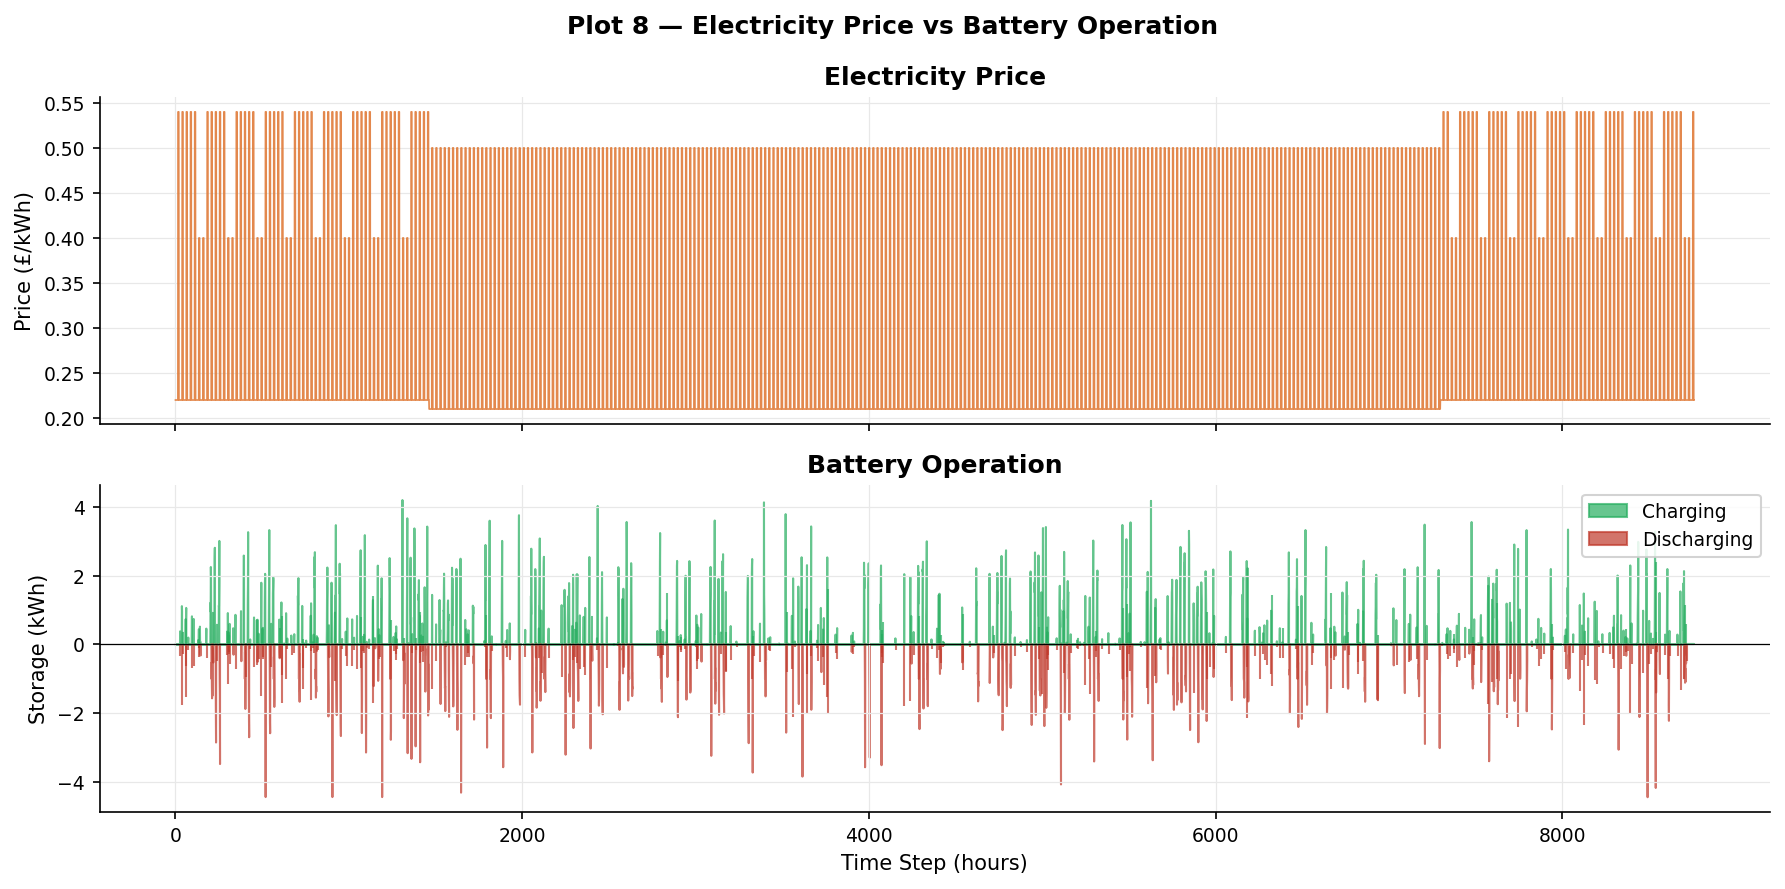

In [44]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 8 — Electricity price vs battery operation
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(df['time_step'], df['electricity_price'], color=ORANGE, lw=0.8, alpha=0.9)
ax1.set_ylabel('Price (£/kWh)')
ax1.set_title('Electricity Price')

ax2.fill_between(df['time_step'], df['storage_electricity_consumption'], 0,
                 where=(df['storage_electricity_consumption'] >= 0),
                 color=GREEN, alpha=0.7, label='Charging')
ax2.fill_between(df['time_step'], df['storage_electricity_consumption'], 0,
                 where=(df['storage_electricity_consumption'] < 0),
                 color=RED, alpha=0.7, label='Discharging')
ax2.axhline(0, color='black', lw=0.6)
ax2.set_ylabel('Storage (kWh)')
ax2.set_xlabel('Time Step (hours)')
ax2.set_title('Battery Operation')
ax2.legend()

fig.suptitle('Plot 8 — Electricity Price vs Battery Operation', fontweight='bold')
plt.tight_layout()
save(fig, 'plot08_price_vs_battery.png')


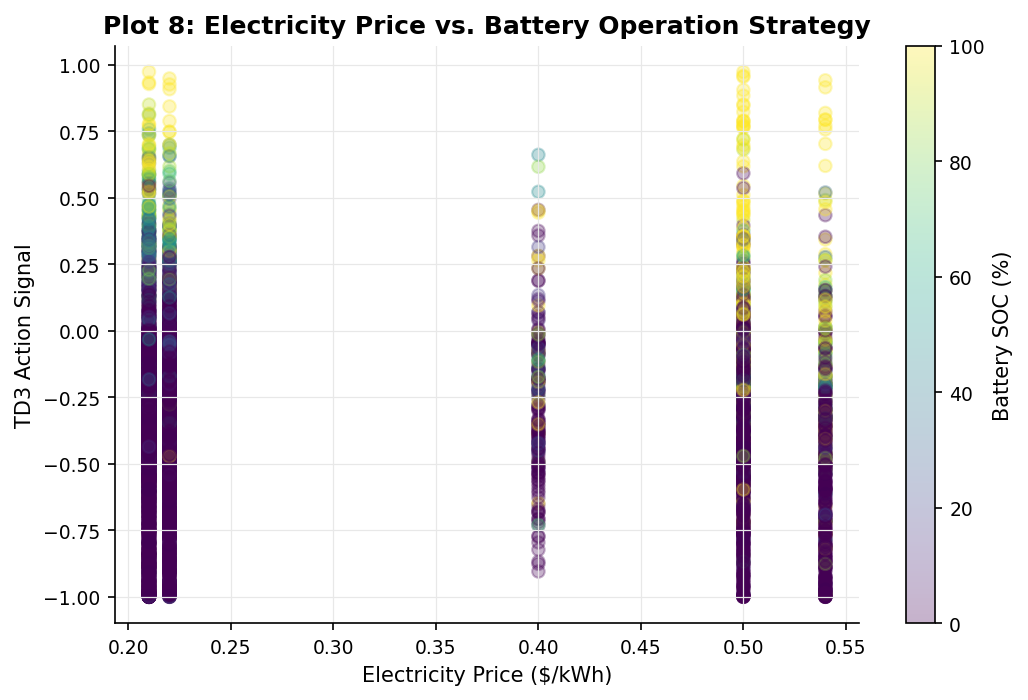

In [ ]:
# ==========================================
# Plot 8: Electricity Price vs Battery Operation new
# ==========================================
plt.figure(figsize=(8, 5))
plt.scatter(df['electricity_price'], df['action'], alpha=0.3, c=df['battery_soc_percent'], cmap='viridis')
plt.colorbar(label='Battery SOC (%)')
plt.xlabel('Electricity Price ($/kWh)')
plt.ylabel('TD3 Action Signal')
plt.title('Plot 8: Electricity Price vs. Battery Operation Strategy')
plt.savefig(f'{output_dir}/Plot_08_Price_vs_Operation.png', dpi=300)
plt.show()


  saved plot09_carbon_vs_battery.png


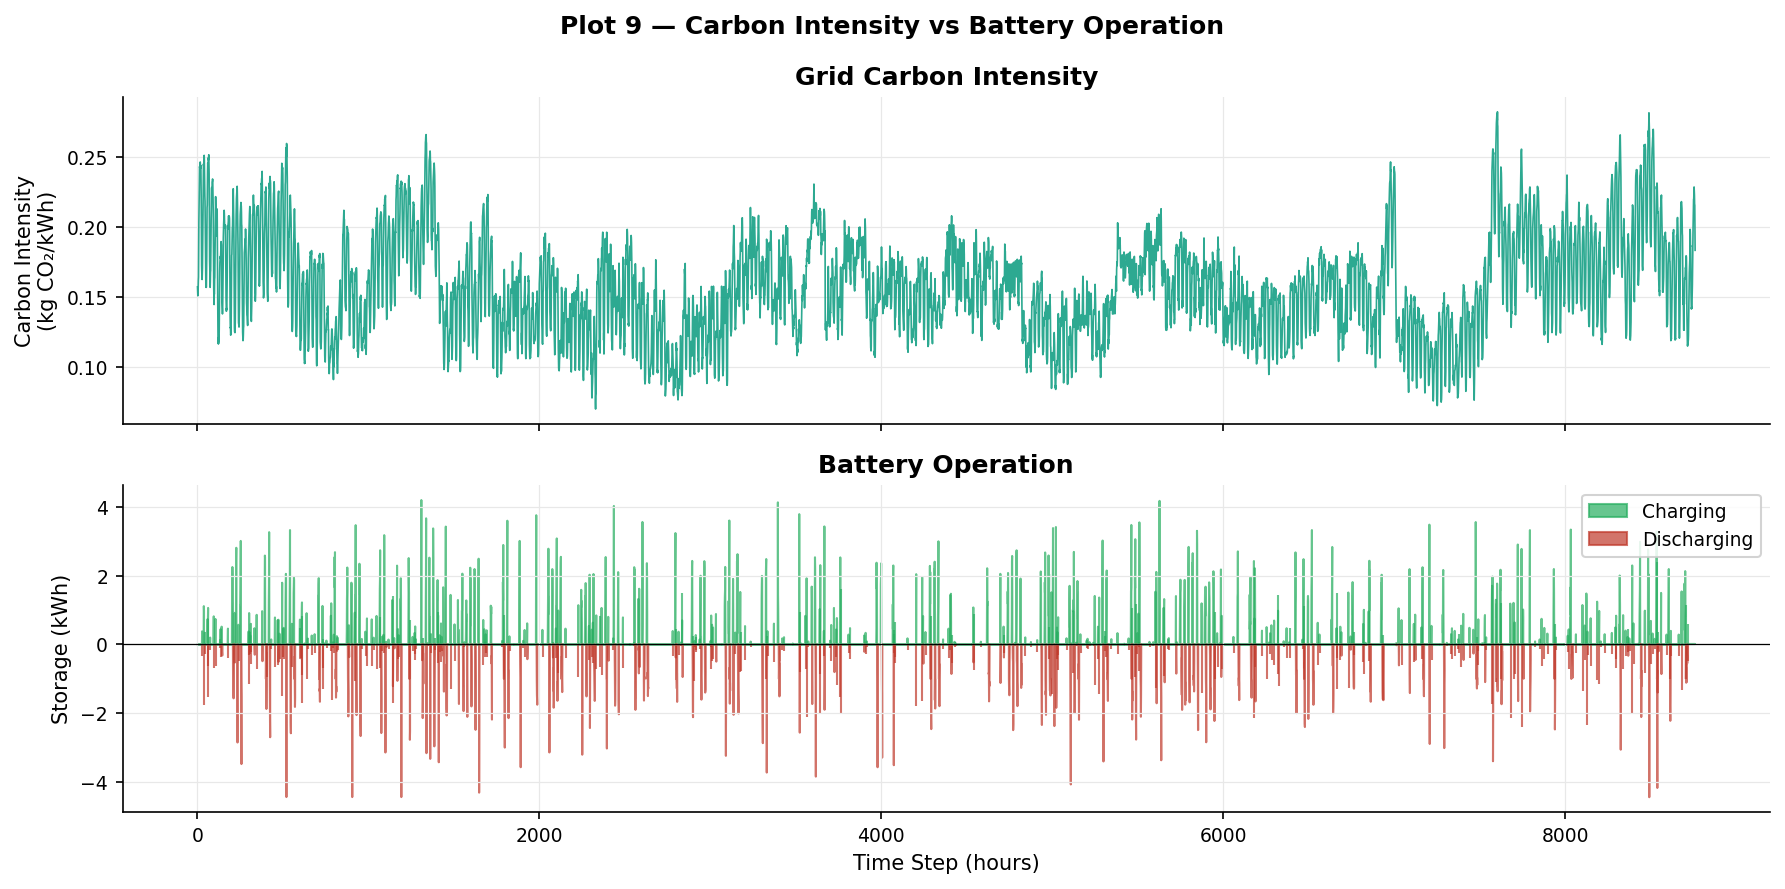

In [24]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 9 — Carbon intensity vs battery operation
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(df['time_step'], df['carbon_intensity'], color=TEAL, lw=0.8, alpha=0.9)
ax1.set_ylabel('Carbon Intensity\n(kg CO₂/kWh)')
ax1.set_title('Grid Carbon Intensity')

ax2.fill_between(df['time_step'], df['storage_electricity_consumption'], 0,
                 where=(df['storage_electricity_consumption'] >= 0),
                 color=GREEN, alpha=0.7, label='Charging')
ax2.fill_between(df['time_step'], df['storage_electricity_consumption'], 0,
                 where=(df['storage_electricity_consumption'] < 0),
                 color=RED, alpha=0.7, label='Discharging')
ax2.axhline(0, color='black', lw=0.6)
ax2.set_ylabel('Storage (kWh)')
ax2.set_xlabel('Time Step (hours)')
ax2.set_title('Battery Operation')
ax2.legend()

fig.suptitle('Plot 9 — Carbon Intensity vs Battery Operation', fontweight='bold')
plt.tight_layout()
save(fig, 'plot09_carbon_vs_battery.png')


  saved plot10_pv_allocation.png


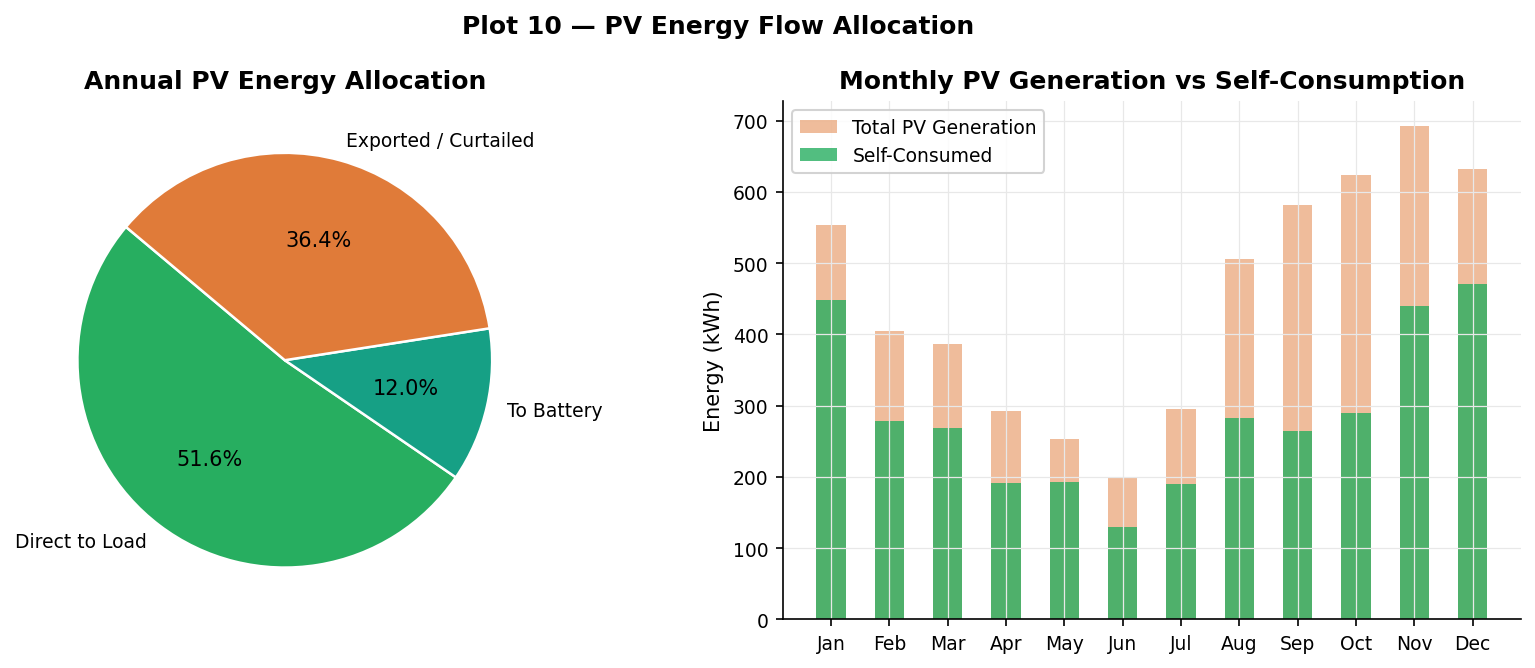

In [25]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 10 — PV energy-flow allocation
# ══════════════════════════════════════════════════════════════════════════════
pv_to_load  = df['pv_to_load'].sum()
pv_to_batt  = df['pv_to_battery'].sum()
pv_exported = (df['pv_generation_positive'] - df['pv_self_consumed']).clip(lower=0).sum()
total_pv    = df['pv_generation_positive'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
slices  = [pv_to_load, pv_to_batt, pv_exported]
clabels = ['Direct to Load', 'To Battery', 'Exported / Curtailed']
ccolors = [GREEN, TEAL, ORANGE]
ax1.pie(slices, labels=clabels, colors=ccolors, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.2})
ax1.set_title('Annual PV Energy Allocation')

months = df['month'].unique()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_order = [m for m in month_order if m in months]
pv_g  = [df.loc[df['month']==m,'pv_generation_positive'].sum() for m in month_order]
pv_sc = [df.loc[df['month']==m,'pv_self_consumed'].sum() for m in month_order]
x = np.arange(len(month_order))
ax2.bar(x, pv_g,  color=ORANGE, alpha=0.5, label='Total PV Generation', width=0.5)
ax2.bar(x, pv_sc, color=GREEN,  alpha=0.8, label='Self-Consumed',        width=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(month_order)
ax2.set_ylabel('Energy (kWh)')
ax2.set_title('Monthly PV Generation vs Self-Consumption')
ax2.legend()

fig.suptitle('Plot 10 — PV Energy Flow Allocation', fontweight='bold')
plt.tight_layout()
save(fig, 'plot10_pv_allocation.png')


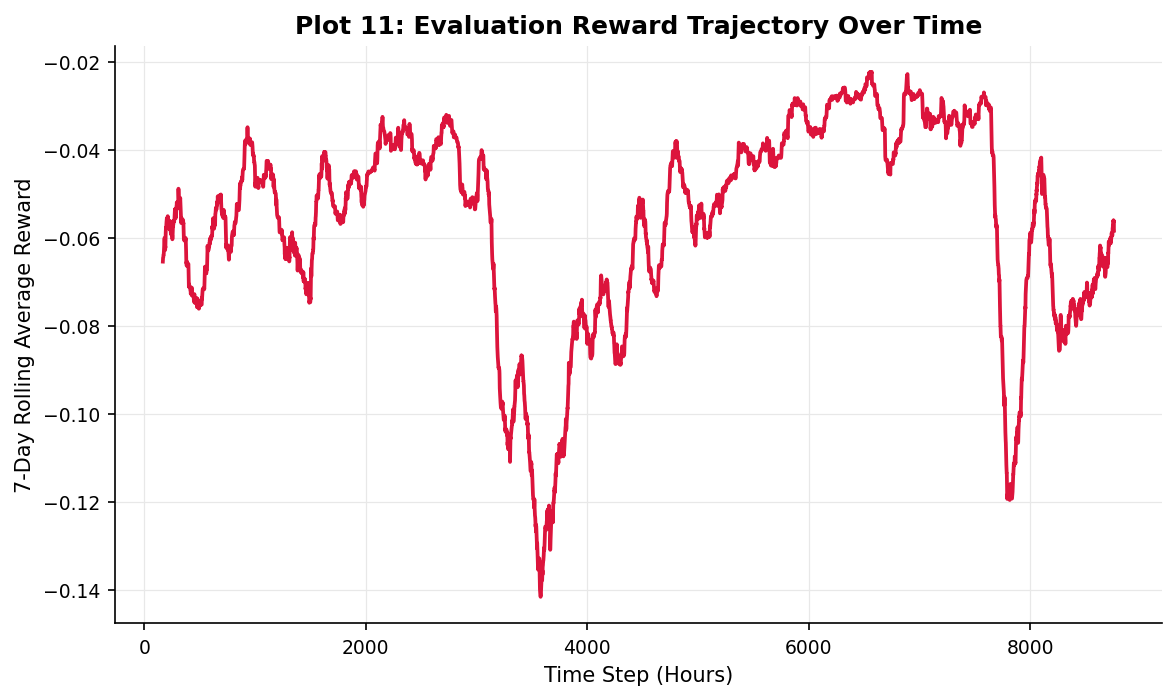

In [33]:
# ==========================================
# Plot 11: Reward Over Time
# ==========================================
plt.figure(figsize=(9, 5))
plt.plot(df['reward'].rolling(window=168).mean(), color='crimson', linewidth=1.8)
plt.xlabel('Time Step (Hours)')
plt.ylabel('7-Day Rolling Average Reward')
plt.title('Plot 11: Evaluation Reward Trajectory Over Time')
plt.savefig(f'{output_dir}/Plot_11_Reward_Over_Time.png', dpi=300)
plt.show()


  saved plot12_reward_decomposition.png


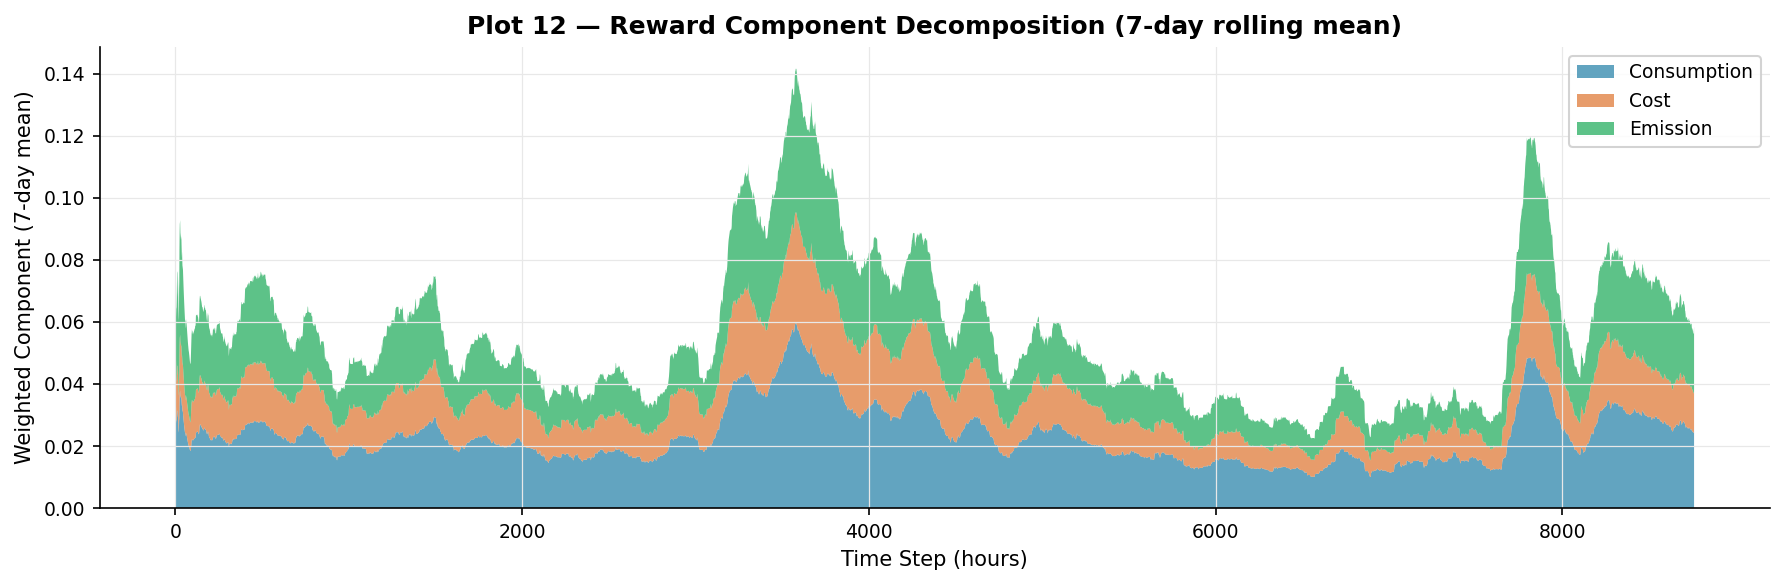

In [27]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 12 — Reward component decomposition (stacked area)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 4))
roll_w = 168
wc = df['weighted_consumption'].rolling(roll_w, min_periods=1).mean()
wco = df['weighted_cost'].rolling(roll_w, min_periods=1).mean()
we = df['weighted_emission'].rolling(roll_w, min_periods=1).mean()
ax.stackplot(df['time_step'], wc, wco, we,
             labels=['Consumption', 'Cost', 'Emission'],
             colors=[BLUE, ORANGE, GREEN], alpha=0.75)
ax.set_xlabel('Time Step (hours)')
ax.set_ylabel('Weighted Component (7-day mean)')
ax.set_title('Plot 12 — Reward Component Decomposition (7-day rolling mean)')
ax.legend(loc='upper right')
plt.tight_layout()
save(fig, 'plot12_reward_decomposition.png')


  saved plot13_norm_distributions.png


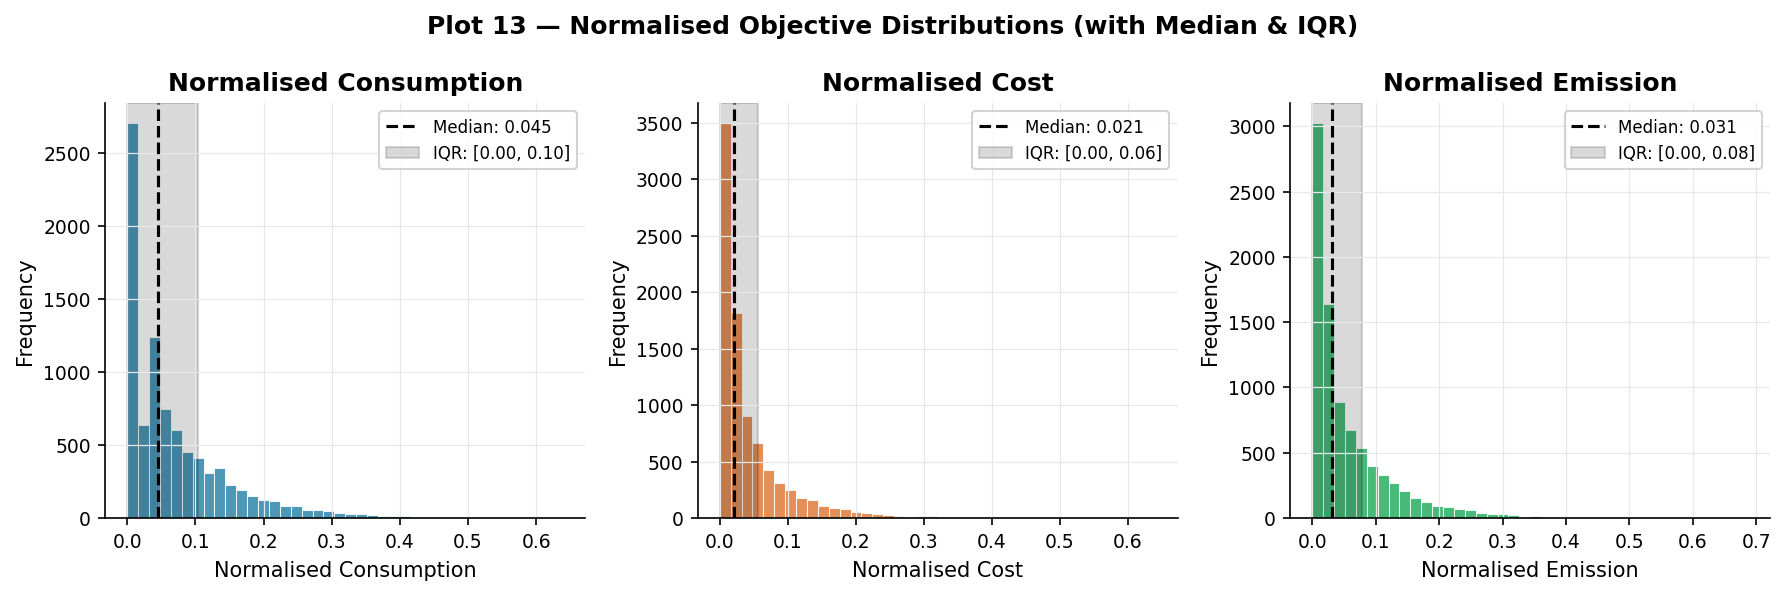

In [28]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 13 — Normalised objective distributions
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
obj_cols = [
    ('normalized_consumption', 'Normalised Consumption', BLUE),
    ('normalized_cost',        'Normalised Cost',        ORANGE),
    ('normalized_emission',    'Normalised Emission',    GREEN),
]
for ax, (col, label, color) in zip(axes, obj_cols):
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    med = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.axvline(med, color='black', lw=1.5, ls='--', label=f'Median: {med:.3f}')
    ax.axvspan(q1, q3, alpha=0.15, color='black', label=f'IQR: [{q1:.2f}, {q3:.2f}]')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(label)
    ax.legend(fontsize=8)
fig.suptitle('Plot 13 — Normalised Objective Distributions (with Median & IQR)', fontweight='bold')
plt.tight_layout()
save(fig, 'plot13_norm_distributions.png')


  saved plot14_mean_daily_profiles.png


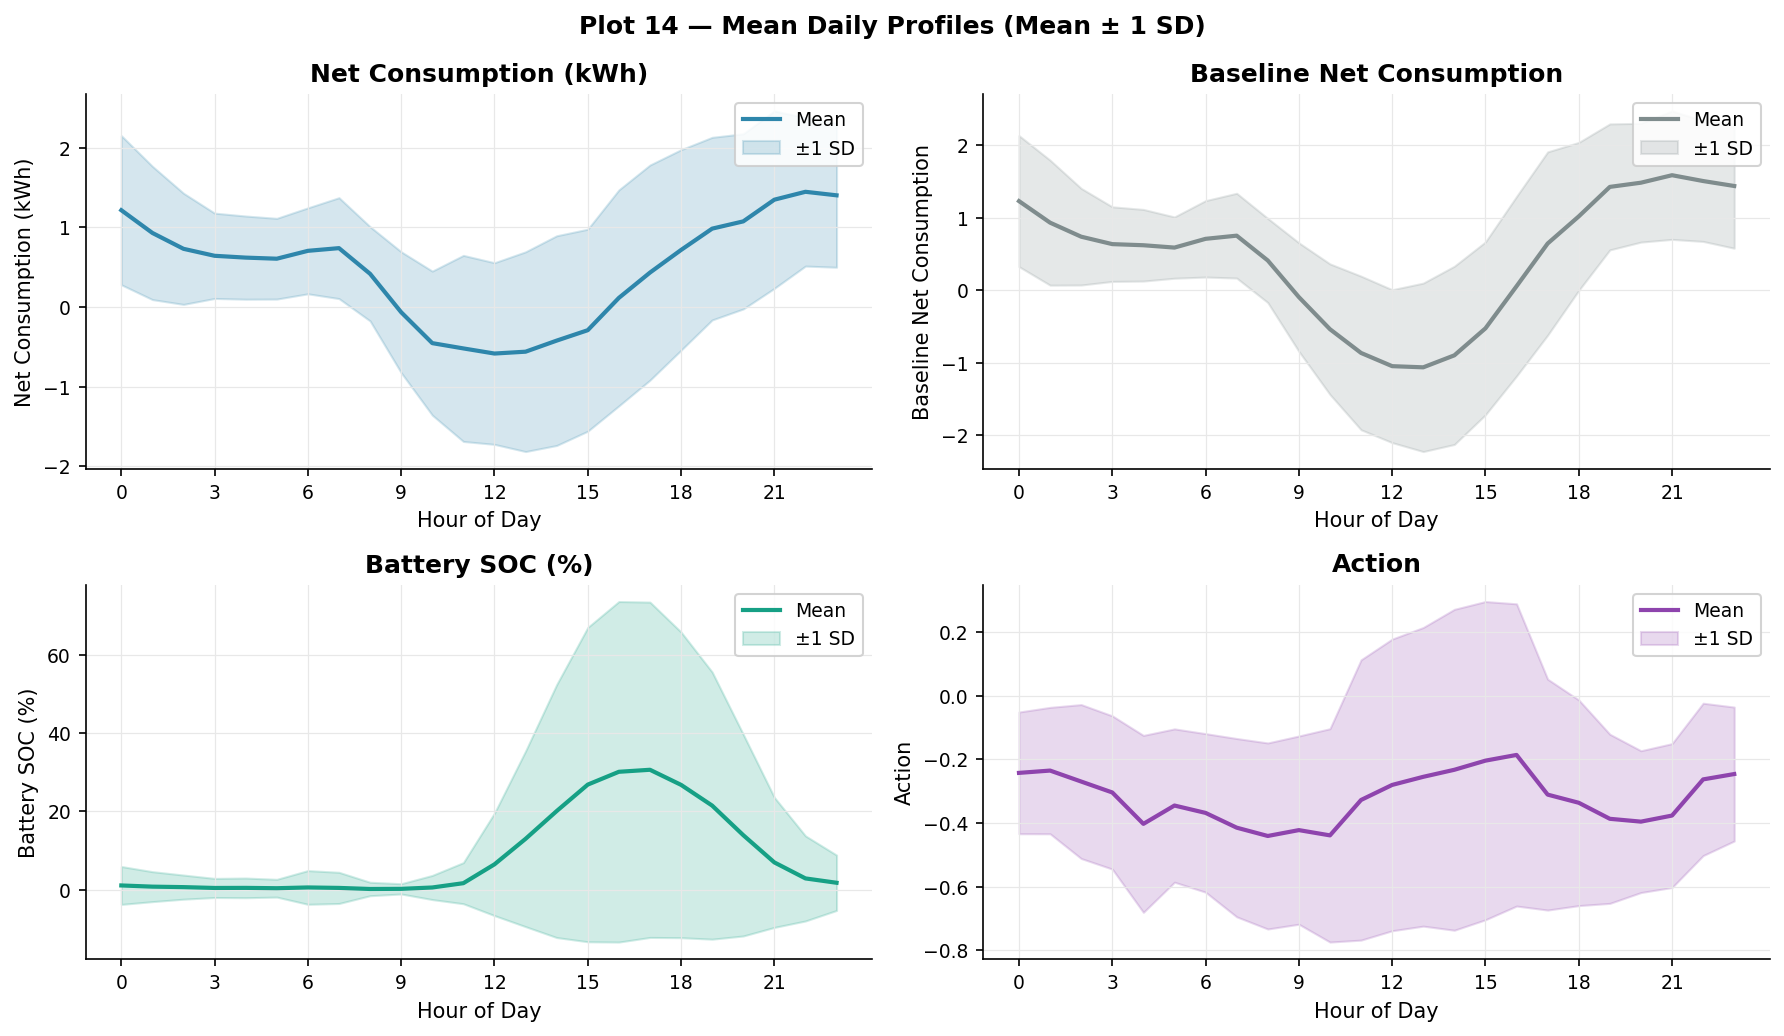

In [29]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 14 — Mean daily profiles (hour-of-day average ± 1 std)
# ══════════════════════════════════════════════════════════════════════════════
vars_14 = {
    'Net Consumption (kWh)':       ('net_consumption', BLUE),
    'Baseline Net Consumption':    ('net_baseline',    GRAY),
    'Battery SOC (%)':             ('battery_soc_percent', TEAL),
    'Action':                      ('action',          PURPLE),
}
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (title, (col, color)) in zip(axes.flat, vars_14.items()):
    grp = df.groupby('hour')[col]
    mu, sd = grp.mean(), grp.std()
    h = np.arange(24)
    ax.plot(h, mu, color=color, lw=2.0, label='Mean')
    ax.fill_between(h, mu - sd, mu + sd, color=color, alpha=0.2, label='±1 SD')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(range(0, 24, 3))
    ax.legend()
fig.suptitle('Plot 14 — Mean Daily Profiles (Mean ± 1 SD)', fontweight='bold')
plt.tight_layout()
save(fig, 'plot14_mean_daily_profiles.png')


  saved plot15_action_heatmap.png


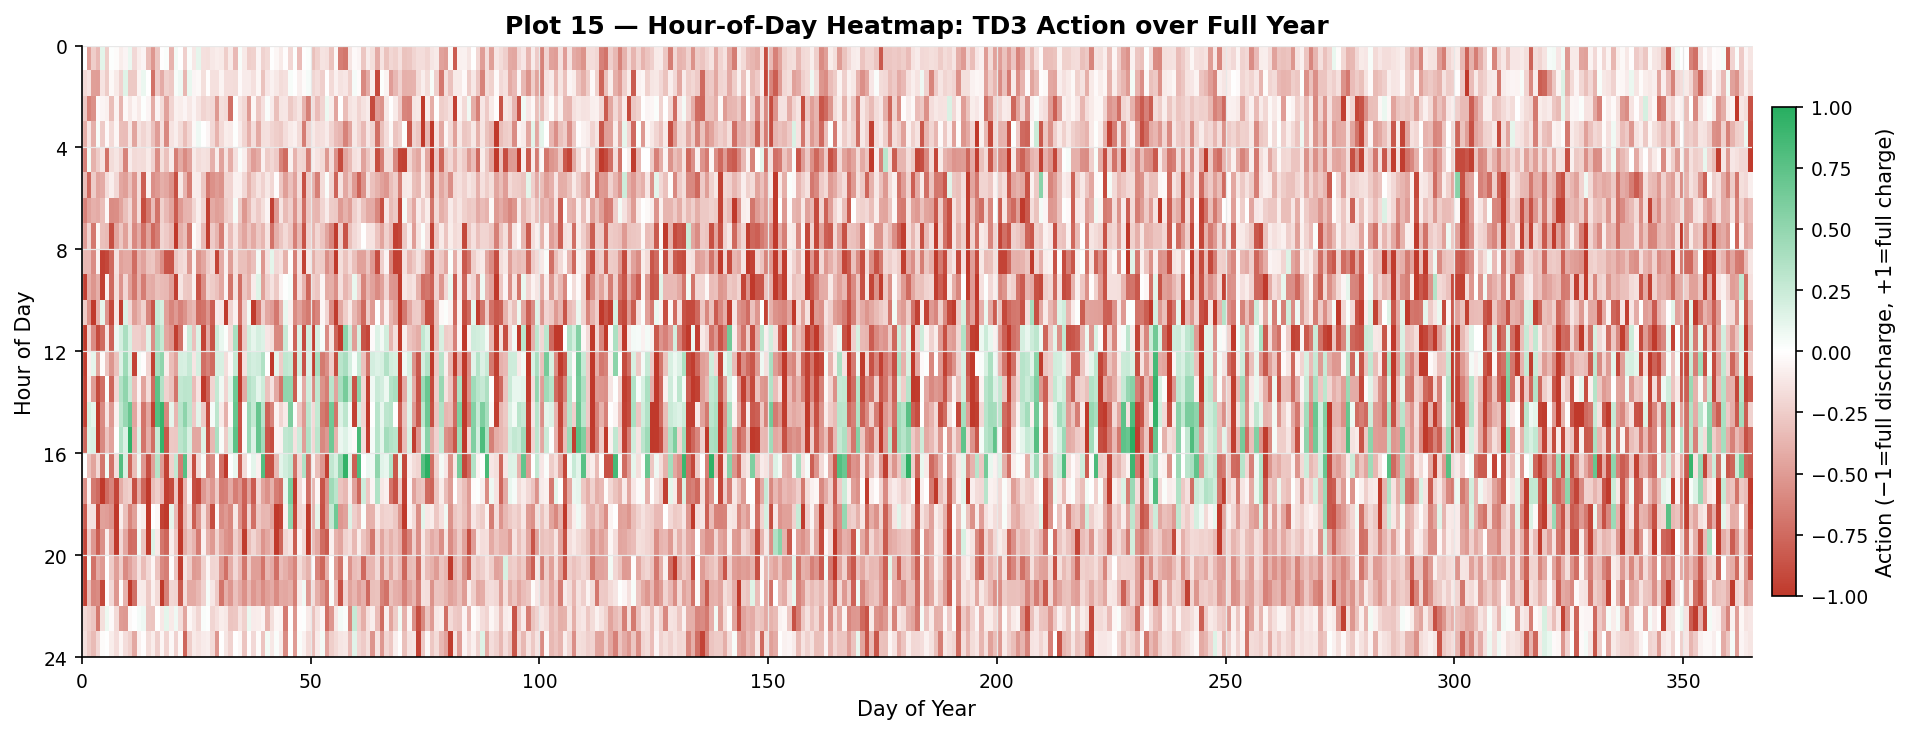

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 15 — Hour-of-day heatmap (action by hour and day-of-year)
# ══════════════════════════════════════════════════════════════════════════════
df['doy'] = df['time_step'] // 24
pivot = df.pivot_table(index='hour', columns='doy', values='action', aggfunc='mean')
pivot = pivot.reindex(index=range(24))

cmap = LinearSegmentedColormap.from_list('rg', [RED, '#FFFFFF', GREEN], N=256)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot, aspect='auto', cmap=cmap, vmin=-1, vmax=1,
               extent=[0, pivot.shape[1], 24, 0])
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
cbar.set_label('Action (−1=full discharge, +1=full charge)')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Hour of Day')
ax.set_yticks(range(0, 25, 4))
ax.set_title('Plot 15 — Hour-of-Day Heatmap: TD3 Action over Full Year')
plt.tight_layout()
save(fig, 'plot15_action_heatmap.png')


  saved plot16_monthly_kpi.png


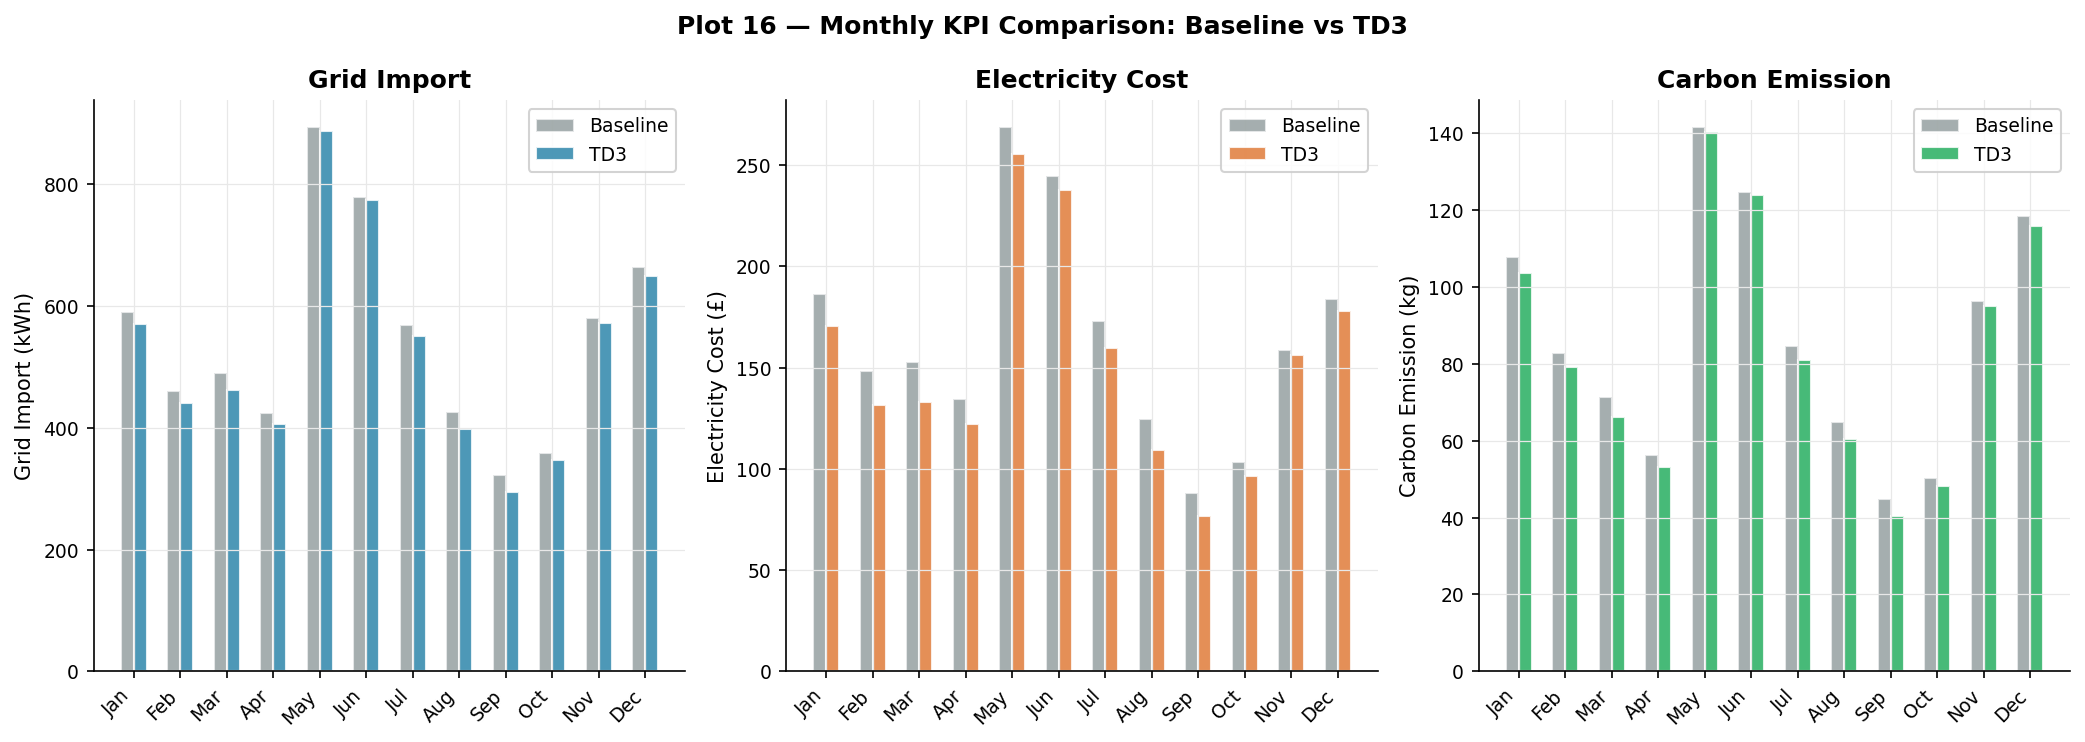

In [82]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 16 — Monthly KPI comparison
# ══════════════════════════════════════════════════════════════════════════════
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months_present = [m for m in month_order if m in df['month'].values]
x = np.arange(len(months_present))
w = 0.28

kpi_sets = [
    ('grid_import',             'baseline_grid_import',             'Grid Import (kWh)',      BLUE),
    ('positive_electricity_cost','positive_baseline_cost',           'Electricity Cost (£)',   ORANGE),
    ('positive_carbon_emission', 'positive_baseline_emission',       'Carbon Emission (kg)',   GREEN),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (ctrl_col, base_col, ylabel, color) in zip(axes, kpi_sets):
    ctrl_m = [df.loc[df['month']==m, ctrl_col].sum() for m in months_present]
    base_m = [df.loc[df['month']==m, base_col].sum() for m in months_present]
    ax.bar(x - w/2, base_m, w, color=GRAY,  alpha=0.7, label='Baseline', edgecolor='white')
    ax.bar(x + w/2, ctrl_m, w, color=color, alpha=0.85, label='TD3',      edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(months_present, rotation=45, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(' (')[0])
    ax.legend()
fig.suptitle('Plot 16 — Monthly KPI Comparison: Baseline vs TD3', fontweight='bold')
plt.tight_layout()
save(fig, 'plot16_monthly_kpi.png')


  saved plot17_correlation_heatmap.png


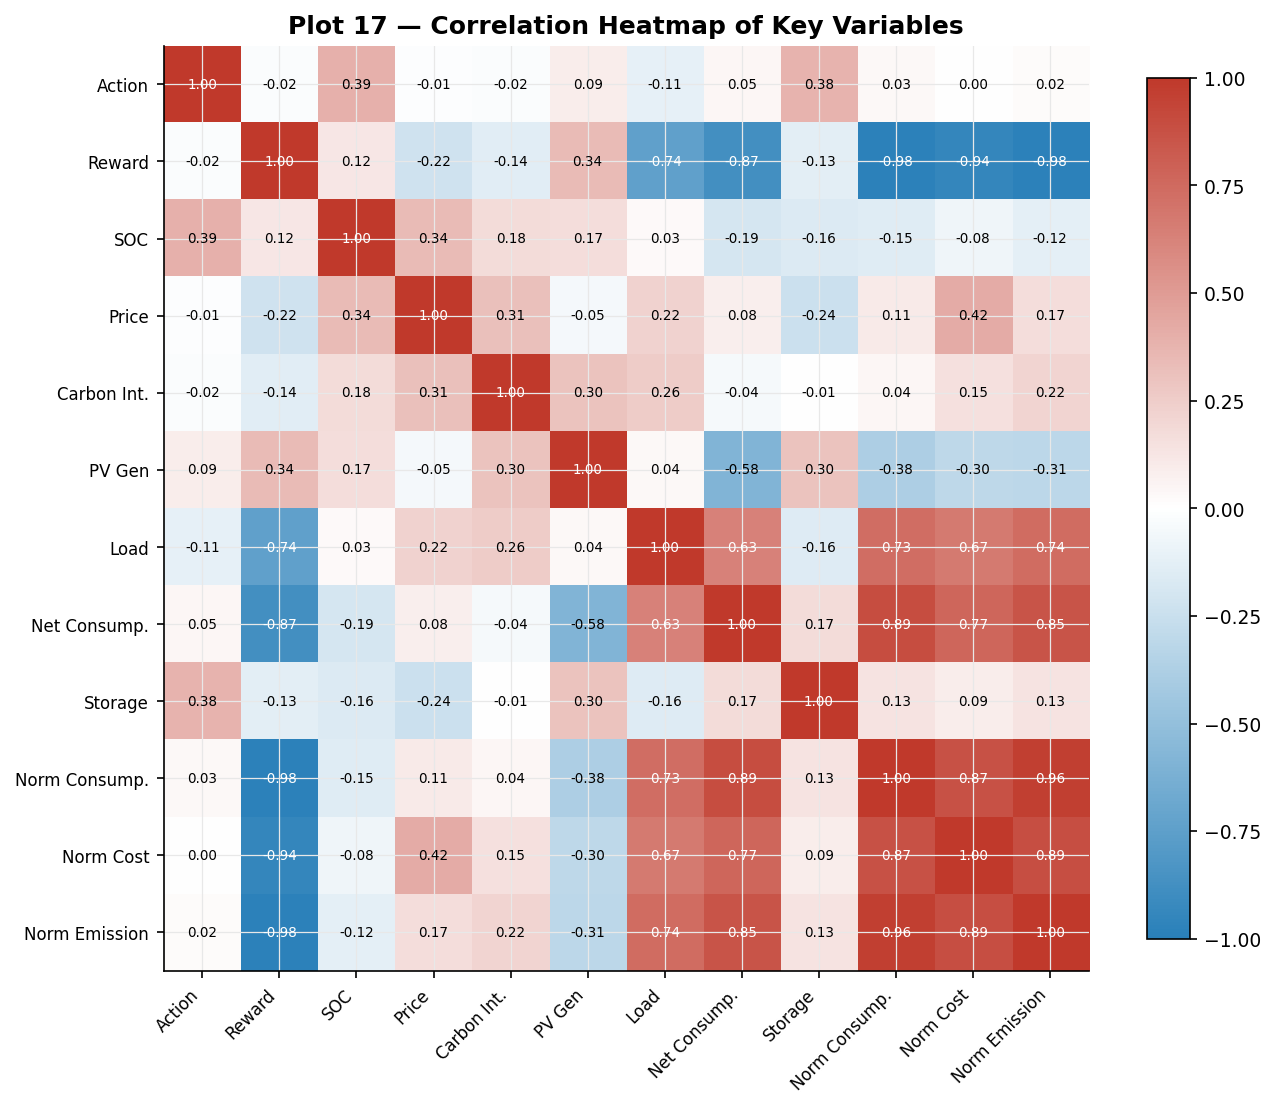

In [83]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 17 — Correlation heatmap
# ══════════════════════════════════════════════════════════════════════════════
corr_cols = ['action', 'reward', 'battery_soc_percent', 'electricity_price',
             'carbon_intensity', 'pv_generation_positive', 'non_shiftable_load',
             'net_consumption', 'storage_electricity_consumption',
             'normalized_consumption', 'normalized_cost', 'normalized_emission']
corr = df[corr_cols].corr()
rename = {
    'action':'Action','reward':'Reward','battery_soc_percent':'SOC',
    'electricity_price':'Price','carbon_intensity':'Carbon Int.',
    'pv_generation_positive':'PV Gen','non_shiftable_load':'Load',
    'net_consumption':'Net Consump.','storage_electricity_consumption':'Storage',
    'normalized_consumption':'Norm Consump.','normalized_cost':'Norm Cost',
    'normalized_emission':'Norm Emission',
}
corr = corr.rename(index=rename, columns=rename)
cmap2 = LinearSegmentedColormap.from_list('bwr', ['#2980B9','white','#C0392B'], N=256)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap=cmap2, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                color='white' if abs(v) > 0.6 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Plot 17 — Correlation Heatmap of Key Variables', fontweight='bold')
plt.tight_layout()
save(fig, 'plot17_correlation_heatmap.png')


  saved plot18_action_vs_storage.png


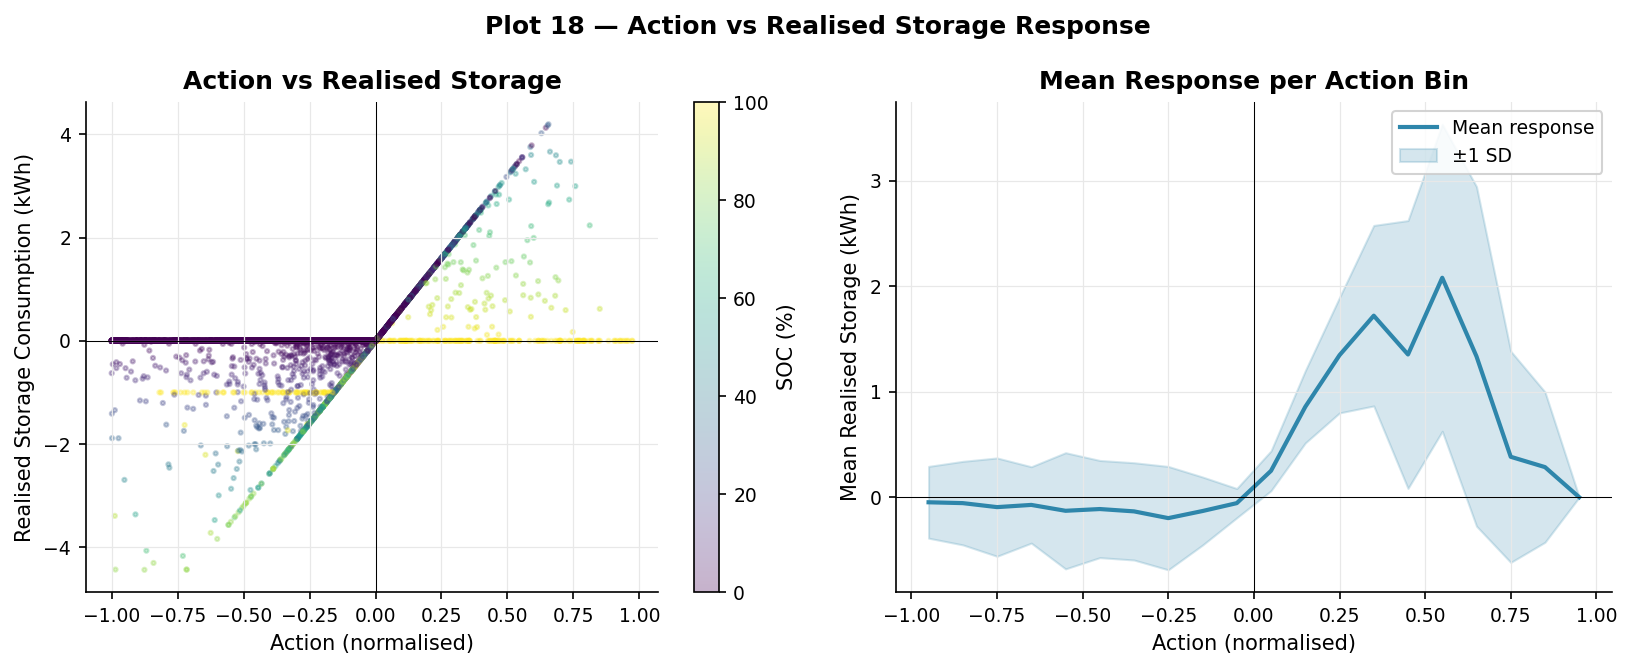

In [84]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 18 — Action vs realised storage response
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax1.scatter(df['action'], df['storage_electricity_consumption'],
                 c=df['battery_soc_percent'], cmap='viridis', alpha=0.3, s=4)
ax1.axhline(0, color='black', lw=0.5); ax1.axvline(0, color='black', lw=0.5)
ax1.set_xlabel('Action (normalised)')
ax1.set_ylabel('Realised Storage Consumption (kWh)')
ax1.set_title('Action vs Realised Storage')
plt.colorbar(sc, ax=ax1, label='SOC (%)')

bins_a = np.linspace(-1, 1, 21)
bin_idx = np.digitize(df['action'], bins_a) - 1
bin_idx = np.clip(bin_idx, 0, len(bins_a)-2)
bin_centers = 0.5 * (bins_a[:-1] + bins_a[1:])
grp_mean, grp_std = [], []
for i in range(len(bin_centers)):
    vals = df.loc[bin_idx == i, 'storage_electricity_consumption']
    grp_mean.append(vals.mean() if len(vals) > 0 else np.nan)
    grp_std.append(vals.std() if len(vals) > 0 else 0)
grp_mean = np.array(grp_mean)
grp_std  = np.array(grp_std)
ax2.plot(bin_centers, grp_mean, color=BLUE, lw=2, label='Mean response')
ax2.fill_between(bin_centers, grp_mean - grp_std, grp_mean + grp_std,
                 color=BLUE, alpha=0.2, label='±1 SD')
ax2.axhline(0, color='black', lw=0.5); ax2.axvline(0, color='black', lw=0.5)
ax2.set_xlabel('Action (normalised)')
ax2.set_ylabel('Mean Realised Storage (kWh)')
ax2.set_title('Mean Response per Action Bin')
ax2.legend()

fig.suptitle('Plot 18 — Action vs Realised Storage Response', fontweight='bold')
plt.tight_layout()
save(fig, 'plot18_action_vs_storage.png')


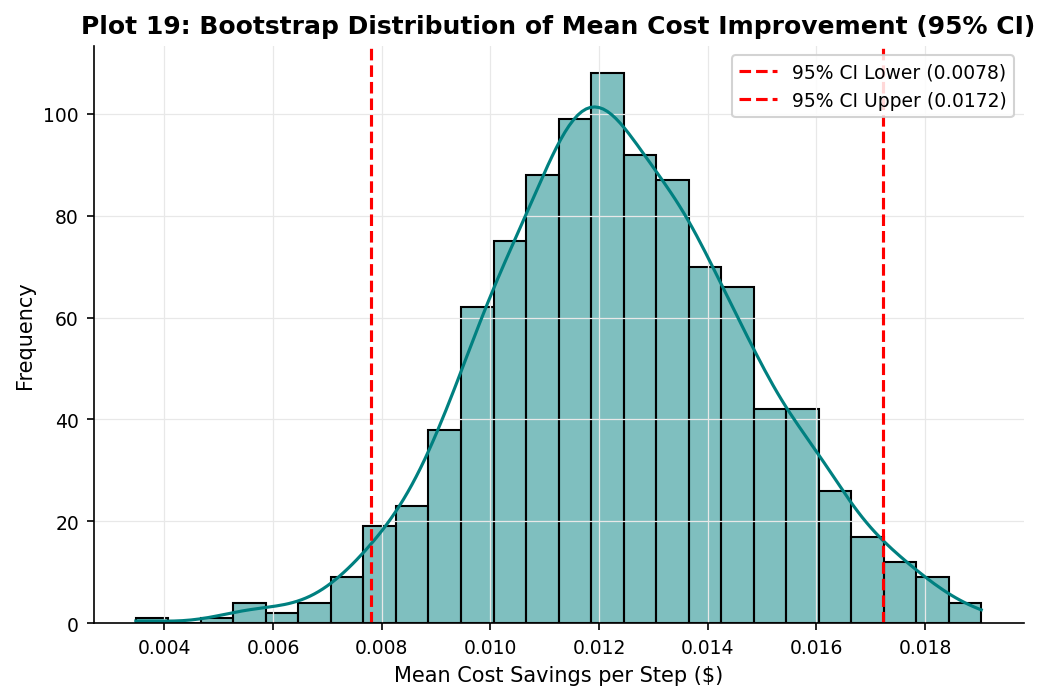

In [ ]:

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(r"D:\transfer_RL\plots for RL\timeseries.csv")
df['hour']  = df['time_step'] % 24
df['day']   = df['time_step'] // 24
df['month'] = pd.cut(
    df['day'],
    bins=[-1,30,58,89,119,150,180,211,242,272,303,333,366],
    labels=['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec']
)
WEEK_START = 20 * 24
week = df.iloc[WEEK_START:WEEK_START+168].copy().reset_index(drop=True)

diffs = df['baseline_cost'] - df['electricity_cost']
boot_means = [np.random.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(1000)]
ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])

plt.figure(figsize=(8, 5))
sns.histplot(boot_means, kde=True, color='teal')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'95% CI Lower ({ci_lower:.4f})')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'95% CI Upper ({ci_upper:.4f})')
plt.xlabel('Mean Cost Savings per Step ($)')
plt.ylabel('Frequency')
plt.title('Plot 19: Bootstrap Distribution of Mean Cost Improvement (95% CI)')
plt.legend()
plt.savefig(f'{output_dir}/Plot_19_Bootstrap_Confidence_Intervals.png', dpi=300)
plt.show()

  saved plot20_cost_carbon_tradeoff.png


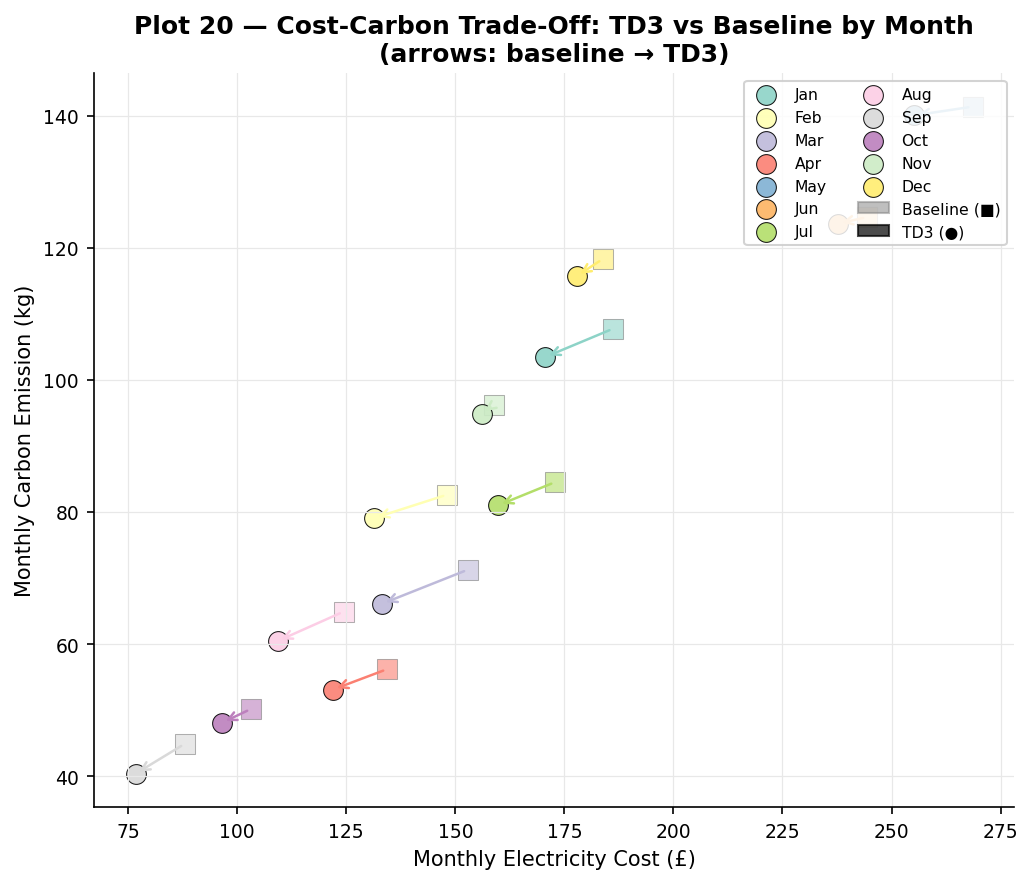


All 20 plots saved.


In [86]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 20 — Cost-carbon trade-off scatterplot
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))
months_list = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cmap20 = plt.get_cmap('tab12' if hasattr(plt.cm,'tab12') else 'Set3')
colors20 = [cmap20(i/12) for i in range(12)]

for i, m in enumerate(months_present):
    sub = df[df['month'] == m]
    if len(sub) == 0:
        continue
    ctrl_cost = sub['positive_electricity_cost'].sum()
    ctrl_emit = sub['positive_carbon_emission'].sum()
    base_cost = sub['positive_baseline_cost'].sum()
    base_emit = sub['positive_baseline_emission'].sum()
    c = colors20[months_list.index(m)]
    ax.scatter(base_cost, base_emit, marker='s', s=90, color=c, alpha=0.6, edgecolors='grey', linewidth=0.5)
    ax.scatter(ctrl_cost, ctrl_emit, marker='o', s=90, color=c, alpha=0.9, edgecolors='black', linewidth=0.5, label=m)
    ax.annotate('', xy=(ctrl_cost, ctrl_emit), xytext=(base_cost, base_emit),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.2))

sq_patch = mpatches.Patch(facecolor='grey', edgecolor='grey', alpha=0.5, label='Baseline (■)')
ci_patch = mpatches.Patch(facecolor='black', edgecolor='black', alpha=0.7, label='TD3 (●)')
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles + [sq_patch, ci_patch], labels_leg + ['Baseline (■)', 'TD3 (●)'],
          fontsize=7.5, ncol=2, loc='upper right')
ax.set_xlabel('Monthly Electricity Cost (£)')
ax.set_ylabel('Monthly Carbon Emission (kg)')
ax.set_title('Plot 20 — Cost-Carbon Trade-Off: TD3 vs Baseline by Month\n(arrows: baseline → TD3)')
plt.tight_layout()
save(fig, 'plot20_cost_carbon_tradeoff.png')

print('\nAll 20 plots saved.')

______________